In [94]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple, Callable, Optional, Sequence
import numpy as np
from scipy.interpolate import RegularGridInterpolator


# ============================================================
# 1. REGIMES
# ============================================================

REGIMES_X_HF = ("X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = REGIMES_X_HF

    def __post_init__(self) -> None:
        allowed = {"D", "X", "HF", "EXIT"}
        invalid = [m for m in self.active_modes if m not in allowed]
        if invalid:
            raise ValueError(f"Invalid regimes: {invalid}")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}

    def has_mode(self, mode: str) -> bool:
        return mode in self.active_modes


# ============================================================
# 2. PARAMETERS
# ============================================================

@dataclass
class ModelParams:
    # Dynamic
    beta: float = 0.95
    delta: float = 0.10
    delta_M: float = 0.10

    phi_H: float = 0.40
    phi_F: float = 0.40
    phi_M: float = 2.0

    xi_H: float = 0.40
    xi_F: float = 0.40
    xi_M: float = 0.0

    # Marginal cost of investment
    q_H: float = 1.0
    q_F: float = 1.0
    q_M: float = 1.0

    # CES / reduced-form parameters
    sigma: float = 5.0
    alpha: float = 0.30

    # Productivity / demand / cost
    A_H: float = 1.0
    A_F: float = 1.0
    Lambda_H: float = 1.0
    Lambda_F: float = 1.2
    w_H: float = 1.0
    w_F: float = 1.0
    tau_X: float = 1.15

    # Fixed operating costs
    f_H_op: float = 0.03
    f_X_op: float = 0.015
    f_F_op: float = 0.03

    # Sunk regime-switching costs
    f_X_E: float = 0.10
    f_F_E: float = 0.10
    f_scope: float = 0.05

    # Technology-capital toggle and intensity
    use_M: bool = False
    alpha_M: float = 0.0

    eps: float = 1e-10

    @property
    def a(self) -> float:
        return (self.sigma - 1.0) / self.sigma

    @property
    def gamma(self) -> float:
        return 1.0 - self.alpha

    @property
    def mu(self) -> float:
        val = 1.0 - self.a * self.gamma
        if val <= 0:
            raise ValueError("Need mu = 1 - a*gamma > 0.")
        return val

    @property
    def rho(self) -> float:
        return self.a / self.mu

    @property
    def kappa(self) -> float:
        return self.alpha * self.rho

# ============================================================
# 3. STATE
# ============================================================

@dataclass
class FirmState:
    KH: float
    KF: float
    s_idx: int
    prev_mode: str
    M: float = 0.0


# ============================================================
# 4. TRANSITIONS AND COSTS
# ============================================================

def investment_cost(i: float, phi: float, q: float = 1.0) -> float:
    return q * i + 0.5 * phi * i**2


def next_capital(K: float, i: float, delta: float) -> float:
    return (1.0 - delta) * K + i


def switching_cost(prev_mode: str, new_mode: str, p: ModelParams) -> float:
    if prev_mode == new_mode:
        return 0.0

    # X -> HF upgrade
    if prev_mode == "X" and new_mode == "HF":
        return p.f_F_E + p.f_scope

    # Reserved for later if D is added
    if prev_mode == "D" and new_mode == "X":
        return p.f_X_E
    if prev_mode == "D" and new_mode == "HF":
        return p.f_X_E + p.f_F_E + p.f_scope

    return 0.0


# ============================================================
# 5. PRODUCTIVITY PROCESS
# ============================================================

def make_constant_productivity_transition(n_s: int) -> np.ndarray:
    """
    Deterministic productivity process:
        s_{t+1} = s_t
    for every grid point.
    """
    return np.eye(n_s)
    

def rouwenhorst(n: int, rho: float, sigma_eps: float, mu: float = 0.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if n < 2:
        raise ValueError("n must be at least 2.")
    if abs(rho) >= 1.0:
        raise ValueError("Need |rho| < 1 for a stationary AR(1).")

    prob = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += prob * P
        P_new[:-1, 1:] += (1.0 - prob) * P
        P_new[1:, :-1] += (1.0 - prob) * P
        P_new[1:, 1:] += prob * P
        P_new[1:-1, :] /= 2.0
        P = P_new

    sigma_z = sigma_eps / np.sqrt(1.0 - rho**2)
    psi = sigma_z * np.sqrt(n - 1)
    z_grid = np.linspace(-psi, psi, n) + mu
    s_grid = np.exp(z_grid)
    return z_grid, s_grid, P


def draw_initial_productivity_indices(
    probs: np.ndarray,
    n_firms: int,
    seed: int | None = None,
) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    rng = np.random.default_rng(seed)
    idx = np.arange(len(probs))
    return rng.choice(idx, size=n_firms, p=probs)


# ============================================================
# 6. PROFIT BLOCK
# ============================================================

def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def omega_H(p: ModelParams) -> float:
    Rbar_H = p.Lambda_H * ((p.a * p.gamma * p.Lambda_H) / p.w_H) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_H * (p.A_H ** p.rho)


def omega_F(p: ModelParams) -> float:
    Rbar_F = p.Lambda_F * ((p.a * p.gamma * p.Lambda_F) / p.w_F) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_F * (p.A_F ** p.rho)


def omega_X(p: ModelParams) -> float:
    chi_X = (p.Lambda_F / (p.tau_X * p.Lambda_H)) ** p.sigma
    Xi_X = p.Lambda_H + p.Lambda_F * (chi_X ** p.a)
    w_X_eff = p.w_H * (1.0 + p.tau_X * chi_X) ** (1.0 / p.gamma)
    Rbar_X = Xi_X * ((p.a * p.gamma * Xi_X) / w_X_eff) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_X * (p.A_H ** p.rho)

def tech_multiplier(KH: float, KF: float, M: float, mode: str, p: ModelParams) -> float:
    """
    Benchmark:
        no technology capital => multiplier = 1

    Extension:
        M is non-rival technology capital that scales operating profits.
        We use (1 + M)^{alpha_M} so that M=0 is a well-defined baseline.
    """
    if not p.use_M or p.alpha_M == 0.0:
        return 1.0
    return (1.0 + max(M, 0.0)) ** p.alpha_M

def profit_X(KH: float, s: float, M: float, p: ModelParams) -> float:
    mult = tech_multiplier(KH=KH, KF=0.0, M=M, mode="X", p=p)
    return omega_X(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) * mult - p.f_H_op - p.f_X_op

def profit_HF(KH: float, KF: float, s: float, M: float, p: ModelParams) -> float:
    mult = tech_multiplier(KH=KH, KF=KF, M=M, mode="HF", p=p)
    home = omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho)
    foreign = omega_F(p) * _safe_power(KF, p.kappa, p.eps) * (s ** p.rho)
    return (home + foreign) * mult - p.f_H_op - p.f_F_op


def flow_profit(mode: str, KH: float, KF: float, s: float, M: float, p: ModelParams) -> float:
    if mode == "X":
        return profit_X(KH, s, M, p)
    if mode == "HF":
        return profit_HF(KH, KF, s, M, p)
    if mode == "D":
        mult = tech_multiplier(KH=KH, KF=0.0, M=M, mode="D", p=p)
        return omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) * mult - p.f_H_op
    raise ValueError(f"Unknown mode: {mode}")

# ============================================================
# 7. TERMINAL VALUE
# ============================================================

def terminal_value(KH: float, KF: float, M: float, p: ModelParams) -> float:
    return p.xi_H * KH + p.xi_F * KF + p.xi_M * M


# ============================================================
# 8. INTERPOLATION HELPERS
# ============================================================

def _clip(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def build_value_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    for pm, prev_mode in enumerate(cfg.active_modes):
        for k in range(len(s_grid)):
            interps[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                V[pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])
    return value_obj


# ============================================================
# 8B. PRECOMPUTED EXPECTED CONTINUATION OBJECTS
# ============================================================

def build_expected_grid_from_markov(
    V_next: np.ndarray,
    P: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    Precompute beta * E[V_next | current s].

    V_next shape: (n_prev_mode, n_KH, n_KF, n_s_next)
    Returns:
        EV shape: (n_prev_mode, n_KH, n_KF, n_s_current)
    """
    n_prev, n_KH, n_KF, n_s_next = V_next.shape
    n_s_cur = P.shape[0]

    EV = np.empty((n_prev, n_KH, n_KF, n_s_cur))
    for pm in range(n_prev):
        for s_cur in range(n_s_cur):
            EV[pm, :, :, s_cur] = beta * np.tensordot(
                V_next[pm, :, :, :],
                P[s_cur, :],
                axes=([2], [0]),
            )
    return EV


def build_expected_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    EV: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    n_index = EV.shape[3]

    for pm, prev_mode in enumerate(cfg.active_modes):
        for idx in range(n_index):
            interps[(prev_mode, idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                EV[pm, :, :, idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_expected_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def EV_obj(prev_mode: str, KH: float, KF: float, idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, idx)](np.array([[KHc, KFc]]))[0])

    return EV_obj

# ============================================================
# 9. FAST HELPERS
# ============================================================

def make_constant_productivity_transition(n_s: int) -> np.ndarray:
    """
    Deterministic productivity process:
        s_{t+1} = s_t
    """
    return np.eye(n_s)


def nearest_index(grid: np.ndarray, x: float) -> int:
    return int(np.argmin(np.abs(grid - x)))


def local_index_window(center: int, n: int, radius: int) -> np.ndarray:
    lo = max(center - radius, 0)
    hi = min(center + radius, n - 1)
    return np.arange(lo, hi + 1)


# ============================================================
# 10. PERIOD-2: CLOSED-FORM KKT (NO GRID SEARCH)
# ============================================================

def period2_investment_kkt(p: ModelParams) -> Tuple[float, float]:
    """
    Closed-form period-2 investment from KKT:

        q_H + phi_H * i_H,2 = beta * xi_H
        q_F + phi_F * i_F,2 = beta * xi_F

    with non-negativity.
    """
    iH = max((p.beta * p.xi_H - p.q_H) / p.phi_H, 0.0)
    iF = max((p.beta * p.xi_F - p.q_F) / p.phi_F, 0.0)
    return float(iH), float(iF)


def branch_value_t2_fast(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
    M: float = 0.0,
) -> Dict[str, float]:
    iH, iF = period2_investment_kkt(p)

    KH3 = next_capital(KH, iH, p.delta)
    KF3 = next_capital(KF, iF, p.delta)

    pi = flow_profit(mode, KH, KF, s, M, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
    cont = p.beta * terminal_value(KH3, KF3, M, p)

    value = pi - switch - adjust + cont

    return {
        "mode": mode,
        "value": value,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "KH_next": KH3,
        "KF_next": KF3,
        "continuation": cont,
    }


def solve_period2_state_fast(
    KH: float,
    KF: float,
    s: float,
    prev_mode: str,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    branches = {
        mode: branch_value_t2_fast(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH,
            KF=KF,
            s=s,
            p=p,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period2_grid_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, np.ndarray]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V2 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, s in enumerate(s_grid):
                    sol = solve_period2_state_fast(
                        KH=KH,
                        KF=KF,
                        s=s,
                        prev_mode=prev_mode,
                        p=p,
                        cfg=cfg,
                    )
                    best = sol["best"]

                    V2[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]
                    KH_next_star[pm, i, j, k] = best["KH_next"]
                    KF_next_star[pm, i, j, k] = best["KF_next"]

    V2_interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V2, cfg)
    V2_obj = make_value_callable(KH_grid, KF_grid, V2_interps)

    return {
        "V2": V2,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": V2_interps,
        "value_callable": V2_obj,
    }


# ============================================================
# 11. PERIOD-1 / PERIOD-0: LOCAL SEARCH OVER NEXT K
# ============================================================

def solve_branch_local_nextK(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s_idx: int,
    s_grid: np.ndarray,
    EV_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, float]:
    """
    Local search over next-period capital grid points.

    Start around depreciated current capital, search +/- radius on each grid.
    If the maximizer is on the edge of the window, recenter and search again.
    """
    s = float(s_grid[s_idx])

    center_H = nearest_index(KH_grid, (1.0 - p.delta) * KH)
    center_F = nearest_index(KF_grid, (1.0 - p.delta) * KF)

    n_H = len(KH_grid)
    n_F = len(KF_grid)
    visited = set()

    best: Optional[Dict[str, float]] = None

    for _ in range(max_expansions):
        key = (center_H, center_F)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius)
        idx_F = local_index_window(center_F, n_F, radius)

        best_val = -np.inf
        best_idx: Optional[Tuple[int, int]] = None
        best_local: Optional[Dict[str, float]] = None

        if mode == "D":
            idx_F = np.array([nearest_index(KF_grid, (1.0 - p.delta) * KF)])

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta) * KH
            if iH < -1e-12:
                continue

            for iF_idx in idx_F:
                KF_next = float(KF_grid[iF_idx])
                iF = KF_next - (1.0 - p.delta) * KF

                if mode == "D":
                    iF = 0.0
                    KF_next = float((1.0 - p.delta) * KF)

                if iF < -1e-12:
                    continue

                pi = flow_profit(mode, KH, KF, s, 0.0, p)
                switch = switching_cost(prev_mode, mode, p)
                adjust = (
                    investment_cost(iH, p.phi_H, p.q_H)
                    + investment_cost(iF, p.phi_F, p.q_F)
                )
                EV = EV_obj(mode, KH_next, KF_next, s_idx)

                val = pi - switch - adjust + EV

                if val > best_val:
                    best_val = val
                    best_idx = (iH_idx, iF_idx)
                    best_local = {
                        "mode": mode,
                        "value": val,
                        "profit": pi,
                        "switch_cost": switch,
                        "iH": float(iH),
                        "iF": float(iF),
                        "KH_next": KH_next,
                        "KF_next": KF_next,
                        "EV": EV,
                    }

        assert best_idx is not None
        assert best_local is not None
        best = best_local

        iH_idx, iF_idx = best_idx
        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))
        hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))

        if hit_edge_H or hit_edge_F:
            center_H, center_F = iH_idx, iF_idx
            continue

        break

    assert best is not None
    return best

def solve_period1_state_fast(
    KH1: float,
    KF1: float,
    s1_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    EV2_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    branches = {
        mode: solve_branch_local_nextK(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH1,
            KF=KF1,
            s_idx=s1_idx,
            s_grid=s_grid,
            EV_obj=EV2_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            radius=radius,
            max_expansions=max_expansions,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }

def solve_period1_grid_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period2_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, np.ndarray]:
    EV2_grid = build_expected_grid_from_markov(
        V_next=period2_sol["V2"],
        P=P,
        beta=p.beta,
    )
    EV2_interps = build_expected_interpolators(KH_grid, KF_grid, EV2_grid, cfg)
    EV2_obj = make_expected_value_callable(KH_grid, KF_grid, EV2_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V1 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, _ in enumerate(s_grid):
                    sol = solve_period1_state_fast(
                        KH1=KH,
                        KF1=KF,
                        s1_idx=k,
                        prev_mode=prev_mode,
                        s_grid=s_grid,
                        EV2_obj=EV2_obj,
                        p=p,
                        KH_grid=KH_grid,
                        KF_grid=KF_grid,
                        cfg=cfg,
                        radius=radius,
                        max_expansions=max_expansions,
                    )
                    best = sol["best"]

                    V1[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]
                    KH_next_star[pm, i, j, k] = best["KH_next"]
                    KF_next_star[pm, i, j, k] = best["KF_next"]

    V1_interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V1, cfg)
    V1_value_obj = make_value_callable(KH_grid, KF_grid, V1_interps)

    return {
        "V1": V1,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": V1_interps,
        "value_callable": V1_value_obj,
        "period2_expected_grid": EV2_grid,
        "period2_expected_interpolators": EV2_interps,
        "period2_expected_callable": EV2_obj,
    }

def solve_period0_state_fast(
    KH0: float,
    KF0: float,
    s0_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    EV1_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    branches = {
        mode: solve_branch_local_nextK(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH0,
            KF=KF0,
            s_idx=s0_idx,
            s_grid=s_grid,
            EV_obj=EV1_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            radius=radius,
            max_expansions=max_expansions,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }

def solve_period0_grid_fast(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period1_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, np.ndarray]:
    EV1_grid = build_expected_grid_from_markov(
        V_next=period1_sol["V1"],
        P=P,
        beta=p.beta,
    )
    EV1_interps = build_expected_interpolators(KH_grid, KF_grid, EV1_grid, cfg)
    EV1_obj = make_expected_value_callable(KH_grid, KF_grid, EV1_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V0 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, _ in enumerate(s_grid):
                    sol = solve_period0_state_fast(
                        KH0=KH,
                        KF0=KF,
                        s0_idx=k,
                        prev_mode=prev_mode,
                        s_grid=s_grid,
                        EV1_obj=EV1_obj,
                        p=p,
                        KH_grid=KH_grid,
                        KF_grid=KF_grid,
                        cfg=cfg,
                        radius=radius,
                        max_expansions=max_expansions,
                    )
                    best = sol["best"]

                    V0[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]
                    KH_next_star[pm, i, j, k] = best["KH_next"]
                    KF_next_star[pm, i, j, k] = best["KF_next"]

    V0_interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V0, cfg)
    V0_value_obj = make_value_callable(KH_grid, KF_grid, V0_interps)

    return {
        "V0": V0,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "interpolators": V0_interps,
        "value_callable": V0_value_obj,
        "period1_expected_grid": EV1_grid,
        "period1_expected_interpolators": EV1_interps,
        "period1_expected_callable": EV1_obj,
    }


# ============================================================
# 12. ANALYTICAL T=2 CUTOFF
# ============================================================

def xhf_cutoff_t2(KH: float, KF: float, prev_mode: str, p: ModelParams) -> float:
    denom = (
        omega_F(p) * _safe_power(KF, p.kappa, p.eps)
        - omega_X(p) * _safe_power(KH, p.kappa, p.eps)
    )
    numer = (
        p.f_F_op - p.f_X_op
        + switching_cost(prev_mode, "HF", p)
        - switching_cost(prev_mode, "X", p)
    )

    if denom <= 0.0:
        return np.inf
    if numer <= 0.0:
        return 0.0

    return float((numer / denom) ** (1.0 / p.rho))


# ============================================================
# 13. FAST POLICY-BASED SIMULATION (NO RE-SOLVING)
# ============================================================

def follow_policy_path_constant_s(
    KH0: float,
    KF0: float,
    s_idx: int,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    grid_sol_p0: Dict[str, np.ndarray],
    grid_sol_p1: Dict[str, np.ndarray],
    grid_sol_p2: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    initial_prev_mode: str = "X",
) -> Dict[str, float]:
    pm0 = cfg.mode_to_index[initial_prev_mode]
    i0 = nearest_index(KH_grid, KH0)
    j0 = nearest_index(KF_grid, KF0)
    k = int(s_idx)

    # t = 0
    mode0 = cfg.index_to_mode[int(grid_sol_p0["policy_mode"][pm0, i0, j0, k])]
    iH0 = float(grid_sol_p0["iH_star"][pm0, i0, j0, k])
    iF0 = float(grid_sol_p0["iF_star"][pm0, i0, j0, k])
    KH1 = float(grid_sol_p0["KH_next_star"][pm0, i0, j0, k])
    KF1 = float(grid_sol_p0["KF_next_star"][pm0, i0, j0, k])

    # t = 1
    pm1 = cfg.mode_to_index[mode0]
    i1 = nearest_index(KH_grid, KH1)
    j1 = nearest_index(KF_grid, KF1)

    mode1 = cfg.index_to_mode[int(grid_sol_p1["policy_mode"][pm1, i1, j1, k])]
    iH1 = float(grid_sol_p1["iH_star"][pm1, i1, j1, k])
    iF1 = float(grid_sol_p1["iF_star"][pm1, i1, j1, k])
    KH2 = float(grid_sol_p1["KH_next_star"][pm1, i1, j1, k])
    KF2 = float(grid_sol_p1["KF_next_star"][pm1, i1, j1, k])

    # t = 2
    pm2 = cfg.mode_to_index[mode1]
    i2 = nearest_index(KH_grid, KH2)
    j2 = nearest_index(KF_grid, KF2)

    mode2 = cfg.index_to_mode[int(grid_sol_p2["policy_mode"][pm2, i2, j2, k])]
    iH2 = float(grid_sol_p2["iH_star"][pm2, i2, j2, k])
    iF2 = float(grid_sol_p2["iF_star"][pm2, i2, j2, k])
    KH3 = float(grid_sol_p2["KH_next_star"][pm2, i2, j2, k])
    KF3 = float(grid_sol_p2["KF_next_star"][pm2, i2, j2, k])

    s_val = float(s_grid[k])
    cutoff2 = xhf_cutoff_t2(KH=KH2, KF=KF2, prev_mode=mode1, p=p)

    return {
        "KH0": float(KH_grid[i0]),
        "KF0": float(KF_grid[j0]),
        "s0_idx": k,
        "s0": s_val,
        "mode0": mode0,
        "iH0": iH0,
        "iF0": iF0,

        "KH1": KH1,
        "KF1": KF1,
        "mode1": mode1,
        "iH1": iH1,
        "iF1": iF1,

        "KH2": KH2,
        "KF2": KF2,
        "mode2": mode2,
        "iH2": iH2,
        "iF2": iF2,

        "KH3": KH3,
        "KF3": KF3,
        "s2": s_val,
        "s2_cutoff_XHF": cutoff2,
        "above_cutoff_t2": bool(s_val >= cutoff2),
        "scrap_value_t3": terminal_value(KH3, KF3, 0.0, p),
    }


def choose_two_types_one_s(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    chosen_s_idx: int,
    grid_sol_p0: Dict[str, np.ndarray],
    grid_sol_p1: Dict[str, np.ndarray],
    grid_sol_p2: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    initial_prev_mode: str = "X",
) -> Dict[str, object]:
    """
    Search over KH0 with KF0 = 0 and a single chosen s.
    Keep only initial states in E_X, then select:
      - one type that ends in HF by t=2
      - one type that stays in X by t=2
    """
    pm_x = cfg.mode_to_index[initial_prev_mode]
    x_idx = cfg.mode_to_index["X"]
    j0 = nearest_index(KF_grid, 0.0)
    k = int(chosen_s_idx)

    candidates = []

    for i, KH0 in enumerate(KH_grid):
        if grid_sol_p0["policy_mode"][pm_x, i, j0, k] != x_idx:
            continue

        row = follow_policy_path_constant_s(
            KH0=float(KH0),
            KF0=float(KF_grid[j0]),
            s_idx=k,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            s_grid=s_grid,
            grid_sol_p0=grid_sol_p0,
            grid_sol_p1=grid_sol_p1,
            grid_sol_p2=grid_sol_p2,
            p=p,
            cfg=cfg,
            initial_prev_mode=initial_prev_mode,
        )
        row["initial_profit_X"] = flow_profit("X", row["KH0"], row["KF0"], row["s0"], 0.0, p)
        candidates.append(row)

    future_hf = [c for c in candidates if c["mode2"] == "HF"]
    stay_x = [c for c in candidates if c["mode2"] == "X"]

    type_future_hf = None if not future_hf else min(future_hf, key=lambda c: c["KH0"])
    type_stay_x = None if not stay_x else max(stay_x, key=lambda c: c["KH0"])

    return {
        "future_hf": type_future_hf,
        "stay_x": type_stay_x,
        "all_candidates": candidates,
    }

def print_path_summary(row: Dict[str, float], label: str) -> None:
    print(f"\n=== {label} ===")
    print(f"Initial: KH0={row['KH0']:.3f}, KF0={row['KF0']:.3f}, s={row['s0']:.3f}")
    print(f"Modes:   t0={row['mode0']}, t1={row['mode1']}, t2={row['mode2']}")
    print(f"iH path: [{row['iH0']:.3f}, {row['iH1']:.3f}, {row['iH2']:.3f}]")
    print(f"iF path: [{row['iF0']:.3f}, {row['iF1']:.3f}, {row['iF2']:.3f}]")
    print(f"KH path: [{row['KH0']:.3f}, {row['KH1']:.3f}, {row['KH2']:.3f}, {row['KH3']:.3f}]")
    print(f"KF path: [{row['KF0']:.3f}, {row['KF1']:.3f}, {row['KF2']:.3f}, {row['KF3']:.3f}]")
    print(
        f"At t=2: s2={row['s2']:.3f}, "
        f"cutoff={row['s2_cutoff_XHF']:.3f}, "
        f"above_cutoff={row['above_cutoff_t2']}"
    )


# ============================================================
# 14. BUILD A ONE-POINT CONSTANT-s MODEL FOR ANY SCALAR s
# ============================================================
def solve_constant_s_model(
    s_value: float,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    """
    Solve the 3-period model for a single fixed productivity level s_value.
    This uses a one-point productivity grid, so s is deterministic and constant.
    """
    if s_value <= 0.0:
        raise ValueError("Need s_value > 0.")

    s_grid = np.array([float(s_value)])
    P_const = make_constant_productivity_transition(1)

    grid_sol_p2 = solve_period2_grid_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    grid_sol_p1 = solve_period1_grid_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P_const,
        period2_sol=grid_sol_p2,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )

    grid_sol_p0 = solve_period0_grid_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P_const,
        period1_sol=grid_sol_p1,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )

    return {
        "s_value": float(s_value),
        "s_grid": s_grid,
        "P": P_const,          # <- add this
        "P_const": P_const,
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "p": p,
        "cfg": cfg,
        "grid_sol_p0": grid_sol_p0,
        "grid_sol_p1": grid_sol_p1,
        "grid_sol_p2": grid_sol_p2,
    }
# ============================================================
# 15. COLLECT ALL INITIAL EXPORTER STATES E_X FOR A GIVEN s
#     AND FOLLOW THE STORED POLICIES
# ============================================================

def collect_exporter_candidates_constant_s(
    model_bundle: Dict[str, object],
    initial_prev_mode: str = "X",
    KF0_target: float = 0.0,
) -> list[dict]:
    """
    For the solved one-point model, collect all initial states with policy X at t=0
    (i.e. in E_X), fixing KF0 close to KF0_target.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    grid_sol_p0 = model_bundle["grid_sol_p0"]
    grid_sol_p1 = model_bundle["grid_sol_p1"]
    grid_sol_p2 = model_bundle["grid_sol_p2"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]

    pm_x = cfg.mode_to_index[initial_prev_mode]
    x_idx = cfg.mode_to_index["X"]
    j0 = nearest_index(KF_grid, KF0_target)

    candidates = []

    for i, KH0 in enumerate(KH_grid):
        if grid_sol_p0["policy_mode"][pm_x, i, j0, 0] != x_idx:
            continue

        row = follow_policy_path_constant_s(
            KH0=float(KH0),
            KF0=float(KF_grid[j0]),
            s_idx=0,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            s_grid=s_grid,
            grid_sol_p0=grid_sol_p0,
            grid_sol_p1=grid_sol_p1,
            grid_sol_p2=grid_sol_p2,
            p=p,
            cfg=cfg,
            initial_prev_mode=initial_prev_mode,
        )

        row["initial_profit_X"] = flow_profit("X", row["KH0"], row["KF0"], row["s0"], 0.0, p)
        candidates.append(row)

    return candidates


# ============================================================
# 16. CHOOSE TYPE A (high-s, future HF) AND TYPE B (low-s, stay X)
#     WITH CLOSE INITIAL EXPORT PROFITS
# ============================================================

def choose_two_types_different_s(
    model_high_s: Dict[str, object],
    model_low_s: Dict[str, object],
    initial_prev_mode: str = "X",
    require_KH_ordering: bool = True,
) -> Dict[str, object]:
    """
    Type A: taken from the high-s model, must end in HF by t=2.
    Type B: taken from the low-s model, must stay in X by t=2.

    Among all such pairs, choose the pair with the smallest absolute difference
    in initial export profits. Optionally require KH_A < KH_B.
    """
    cand_high = collect_exporter_candidates_constant_s(
        model_bundle=model_high_s,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
    )
    cand_low = collect_exporter_candidates_constant_s(
        model_bundle=model_low_s,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
    )

    future_hf = [c for c in cand_high if c["mode2"] == "HF"]
    stay_x = [c for c in cand_low if c["mode2"] == "X"]

    if len(future_hf) == 0:
        raise ValueError(
            "No high-s exporter in E_X transitions to HF. "
            "Try a higher s_high or lower HF costs."
        )
    if len(stay_x) == 0:
        raise ValueError(
            "No low-s exporter in E_X stays in X. "
            "Try a lower s_low or higher HF costs."
        )

    best_pair = None
    best_gap = np.inf

    for a in future_hf:
        for b in stay_x:
            if require_KH_ordering and not (a["KH0"] < b["KH0"]):
                continue

            gap = abs(a["initial_profit_X"] - b["initial_profit_X"])
            if gap < best_gap:
                best_gap = gap
                best_pair = (a, b)

    if best_pair is None:
        raise ValueError(
            "Could not find a pair with KH_A < KH_B. "
            "Set require_KH_ordering=False or adjust s_high / s_low."
        )

    type_A, type_B = best_pair

    return {
        "type_A": type_A,   # high s, future HF
        "type_B": type_B,   # low s, stay X
        "profit_gap": best_gap,
        "n_future_hf_candidates": len(future_hf),
        "n_stay_x_candidates": len(stay_x),
        "cand_high": cand_high,
        "cand_low": cand_low,
    }


# ============================================================
# 17. SMALL PRINTER FOR THE MATCHED-PAIR EXERCISE
# ============================================================

def print_matched_pair_summary(type_A: dict, type_B: dict, profit_gap: float) -> None:
    print("\n=== Matched two-type exercise ===")
    print(f"Initial export-profit gap: {profit_gap:.6f}")

    print("\nType A: high-s, future HF")
    print(f"  s_A   = {type_A['s0']:.3f}")
    print(f"  KH0_A = {type_A['KH0']:.3f}")
    print(f"  piX_A = {type_A['initial_profit_X']:.6f}")
    print(f"  modes = ({type_A['mode0']}, {type_A['mode1']}, {type_A['mode2']})")

    print("\nType B: low-s, stay X")
    print(f"  s_B   = {type_B['s0']:.3f}")
    print(f"  KH0_B = {type_B['KH0']:.3f}")
    print(f"  piX_B = {type_B['initial_profit_X']:.6f}")
    print(f"  modes = ({type_B['mode0']}, {type_B['mode1']}, {type_B['mode2']})")


    if labels is None:
        labels = [f"firm_{i}" for i in range(len(rows))]

    for label, row in zip(labels, rows):
        print(f"\n=== {label} ===")
        print(f"Initial state: KH0={row['KH0']:.3f}, KF0={row['KF0']:.3f}, s0={row['s0']:.3f}")
        print(f"Modes:   t0={row['mode0']}, t1={row['mode1']}, t2={row['mode2']}")
        print(f"iH path: [{row['iH0']:.3f}, {row['iH1']:.3f}, {row['iH2']:.3f}]")
        print(f"iF path: [{row['iF0']:.3f}, {row['iF1']:.3f}, {row['iF2']:.3f}]")
        print(f"KH path: [{row['KH0']:.3f}, {row['KH1']:.3f}, {row['KH2']:.3f}, {row['KH3']:.3f}]")
        print(f"KF path: [{row['KF0']:.3f}, {row['KF1']:.3f}, {row['KF2']:.3f}, {row['KF3']:.3f}]")
        print(f"At t=2: s2={row['s2']:.3f}, cutoff={row['s2_cutoff_XHF']:.3f}, above_cutoff={row['above_cutoff_t2']}")


# ============================================================
# 17. Stochastic
# ============================================================
def solve_model_fast_bundle(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    radius: int = 7,
    max_expansions: int = 5,
) -> Dict[str, object]:
    """
    Generic fast solver for either:
      - one-point fixed-s model
      - full Markov model on a Rouwenhorst grid
    """
    grid_sol_p2 = solve_period2_grid_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    grid_sol_p1 = solve_period1_grid_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        period2_sol=grid_sol_p2,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )

    grid_sol_p0 = solve_period0_grid_fast(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        s_grid=s_grid,
        P=P,
        period1_sol=grid_sol_p1,
        p=p,
        cfg=cfg,
        radius=radius,
        max_expansions=max_expansions,
    )

    return {
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "s_grid": s_grid,
        "P": P,
        "p": p,
        "cfg": cfg,
        "grid_sol_p0": grid_sol_p0,
        "grid_sol_p1": grid_sol_p1,
        "grid_sol_p2": grid_sol_p2,
    }

def nearest_s_index(s_grid: np.ndarray, s_value: float) -> int:
    return int(np.argmin(np.abs(np.asarray(s_grid) - s_value)))

def collect_initial_exporter_candidates_by_sidx(
    model_bundle: Dict[str, object],
    s_idx: int,
    initial_prev_mode: str = "X",
    KF0_target: float = 0.0,
) -> list[dict]:
    """
    Collect all initial states in E_X for a given initial productivity index.
    Only initial objects are collected here.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]
    grid_sol_p0 = model_bundle["grid_sol_p0"]

    pm_x = cfg.mode_to_index[initial_prev_mode]
    x_idx = cfg.mode_to_index["X"]
    j0 = nearest_index(KF_grid, KF0_target)

    out = []
    for i, KH0 in enumerate(KH_grid):
        if grid_sol_p0["policy_mode"][pm_x, i, j0, s_idx] != x_idx:
            continue

        mode0 = cfg.index_to_mode[int(grid_sol_p0["policy_mode"][pm_x, i, j0, s_idx])]

        row = {
            "KH0": float(KH0),
            "KF0": float(KF_grid[j0]),
            "s0_idx": int(s_idx),
            "s0": float(s_grid[s_idx]),
            "mode0": mode0,
            "iH0": float(grid_sol_p0["iH_star"][pm_x, i, j0, s_idx]),
            "iF0": float(grid_sol_p0["iF_star"][pm_x, i, j0, s_idx]),
            "initial_profit_X": flow_profit("X", float(KH0), float(KF_grid[j0]), float(s_grid[s_idx]), 0.0, p),
        }
        out.append(row)

    return out

def choose_two_types_different_s_markov(
    model_bundle: Dict[str, object],
    s_high_idx: int,
    s_low_idx: int,
    initial_prev_mode: str = "X",
    require_KH_ordering: bool = True,
) -> Dict[str, object]:
    cand_high = collect_initial_exporter_candidates_by_sidx(
        model_bundle=model_bundle,
        s_idx=s_high_idx,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
    )
    cand_low = collect_initial_exporter_candidates_by_sidx(
        model_bundle=model_bundle,
        s_idx=s_low_idx,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
    )

    if len(cand_high) == 0:
        raise ValueError("No exporters in E_X at the chosen high-s index.")
    if len(cand_low) == 0:
        raise ValueError("No exporters in E_X at the chosen low-s index.")

    best_pair = None
    best_gap = np.inf

    for a in cand_high:
        for b in cand_low:
            if require_KH_ordering and not (a["KH0"] < b["KH0"]):
                continue

            gap = abs(a["initial_profit_X"] - b["initial_profit_X"])
            if gap < best_gap:
                best_gap = gap
                best_pair = (a, b)

    if best_pair is None:
        raise ValueError(
            "Could not find a matched pair with KH_A < KH_B. "
            "Try different s_high_idx / s_low_idx or set require_KH_ordering=False."
        )

    type_A, type_B = best_pair

    return {
        "type_A": type_A,
        "type_B": type_B,
        "profit_gap": best_gap,
        "cand_high": cand_high,
        "cand_low": cand_low,
    }

def simulate_many_from_initial_state(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    n_firms: int = 100,
    seed: int = 123,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
) -> Dict[str, object]:
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    P = model_bundle["P"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]

    grid_sol_p0 = model_bundle["grid_sol_p0"]
    grid_sol_p1 = model_bundle["grid_sol_p1"]
    grid_sol_p2 = model_bundle["grid_sol_p2"]

    rng = np.random.default_rng(seed)
    rows = []

    pm0 = cfg.mode_to_index[initial_prev_mode]
    i0 = nearest_index(KH_grid, KH0)
    j0 = nearest_index(KF_grid, KF0)

    for firm_id in range(n_firms):
        # --------------------
        # t = 0
        # --------------------
        k0 = int(s0_idx)
        mode0 = cfg.index_to_mode[int(grid_sol_p0["policy_mode"][pm0, i0, j0, k0])]
        iH0 = float(grid_sol_p0["iH_star"][pm0, i0, j0, k0])
        iF0 = float(grid_sol_p0["iF_star"][pm0, i0, j0, k0])
        KH1 = float(grid_sol_p0["KH_next_star"][pm0, i0, j0, k0])
        KF1 = float(grid_sol_p0["KF_next_star"][pm0, i0, j0, k0])

        # draw or keep s1
        if stochastic:
            k1 = int(rng.choice(np.arange(len(s_grid)), p=P[k0, :]))
        else:
            k1 = k0

        # --------------------
        # t = 1
        # --------------------
        pm1 = cfg.mode_to_index[mode0]
        i1 = nearest_index(KH_grid, KH1)
        j1 = nearest_index(KF_grid, KF1)

        mode1 = cfg.index_to_mode[int(grid_sol_p1["policy_mode"][pm1, i1, j1, k1])]
        iH1 = float(grid_sol_p1["iH_star"][pm1, i1, j1, k1])
        iF1 = float(grid_sol_p1["iF_star"][pm1, i1, j1, k1])
        KH2 = float(grid_sol_p1["KH_next_star"][pm1, i1, j1, k1])
        KF2 = float(grid_sol_p1["KF_next_star"][pm1, i1, j1, k1])

        # draw or keep s2
        if stochastic:
            k2 = int(rng.choice(np.arange(len(s_grid)), p=P[k1, :]))
        else:
            k2 = k1

        # --------------------
        # t = 2
        # --------------------
        pm2 = cfg.mode_to_index[mode1]
        i2 = nearest_index(KH_grid, KH2)
        j2 = nearest_index(KF_grid, KF2)

        mode2 = cfg.index_to_mode[int(grid_sol_p2["policy_mode"][pm2, i2, j2, k2])]
        iH2 = float(grid_sol_p2["iH_star"][pm2, i2, j2, k2])
        iF2 = float(grid_sol_p2["iF_star"][pm2, i2, j2, k2])
        KH3 = float(grid_sol_p2["KH_next_star"][pm2, i2, j2, k2])
        KF3 = float(grid_sol_p2["KF_next_star"][pm2, i2, j2, k2])

        s0 = float(s_grid[k0])
        s1 = float(s_grid[k1])
        s2 = float(s_grid[k2])

        cutoff2 = xhf_cutoff_t2(KH=KH2, KF=KF2, prev_mode=mode1, p=p)

        rows.append({
            "firm_id": firm_id,

            "KH0": float(KH_grid[i0]),
            "KF0": float(KF_grid[j0]),
            "s0_idx": k0,
            "s0": s0,
            "mode0": mode0,
            "iH0": iH0,
            "iF0": iF0,

            "KH1": KH1,
            "KF1": KF1,
            "s1_idx": k1,
            "s1": s1,
            "mode1": mode1,
            "iH1": iH1,
            "iF1": iF1,

            "KH2": KH2,
            "KF2": KF2,
            "s2_idx": k2,
            "s2": s2,
            "mode2": mode2,
            "iH2": iH2,
            "iF2": iF2,

            "KH3": KH3,
            "KF3": KF3,
            "s2_cutoff_XHF": cutoff2,
            "above_cutoff_t2": bool(s2 >= cutoff2),
            "scrap_value_t3": terminal_value(KH3, KF3, 0.0, p),
        })

    return {
        "rows": rows,
        "stochastic": stochastic,
        "n_firms": n_firms,
    }

def summarize_simulation(sim: Dict[str, object], label: str) -> None:
    rows = sim["rows"]

    hf_share = np.mean([r["mode2"] == "HF" for r in rows])
    above_share = np.mean([r["above_cutoff_t2"] for r in rows])

    mean_iF0 = np.mean([r["iF0"] for r in rows])
    mean_iF1 = np.mean([r["iF1"] for r in rows])

    mean_KF2 = np.mean([r["KF2"] for r in rows])
    mean_KH2 = np.mean([r["KH2"] for r in rows])

    print(f"\n=== {label} ===")
    print(f"n firms: {len(rows)}")
    print(f"Share in HF at t=2: {hf_share:.3f}")
    print(f"Share above t=2 cutoff: {above_share:.3f}")
    print(f"Mean iF0: {mean_iF0:.3f}")
    print(f"Mean iF1: {mean_iF1:.3f}")
    print(f"Mean KH2: {mean_KH2:.3f}")
    print(f"Mean KF2: {mean_KF2:.3f}")

# ============================================================
# 18. CHEAP INITIAL BOUNDARY CLOSENESS AT t=0
# ============================================================

def compute_initial_branch_gap_t0(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    s0_idx: int,
    initial_prev_mode: str = "X",
) -> Dict[str, float]:
    """
    Compute the t=0 gap:
        gap_X_minus_HF = W0^X - W0^HF
    using the fast local-search solver.

    Positive gap means the state is in E_X.
    Small positive gap means the exporter is close to the X/HF boundary.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]
    EV1_obj = model_bundle["grid_sol_p0"]["period1_expected_callable"]

    sol = solve_period0_state_fast(
        KH0=KH0,
        KF0=KF0,
        s0_idx=s0_idx,
        prev_mode=initial_prev_mode,
        s_grid=s_grid,
        EV1_obj=EV1_obj,
        p=p,
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        cfg=cfg,
        radius=7,
        max_expansions=5,
    )

    all_branches = sol["all"]
    WX = all_branches["X"]["value"]
    WHF = all_branches["HF"]["value"]

    return {
        "W0_X": float(WX),
        "W0_HF": float(WHF),
        "gap_X_minus_HF": float(WX - WHF),
    }


def collect_exporter_candidates_with_boundary_info(
    model_bundle: Dict[str, object],
    s_idx: int,
    initial_prev_mode: str = "X",
    KF0_target: float = 0.0,
) -> list[dict]:
    """
    Collect initial exporter candidates in E_X at a given s_idx,
    augmented with t=0 boundary closeness.
    """
    base = collect_initial_exporter_candidates_by_sidx(
        model_bundle=model_bundle,
        s_idx=s_idx,
        initial_prev_mode=initial_prev_mode,
        KF0_target=KF0_target,
    )

    out = []
    for row in base:
        gap_info = compute_initial_branch_gap_t0(
            model_bundle=model_bundle,
            KH0=row["KH0"],
            KF0=row["KF0"],
            s0_idx=row["s0_idx"],
            initial_prev_mode=initial_prev_mode,
        )
        merged = dict(row)
        merged.update(gap_info)
        out.append(merged)

    return out


# ============================================================
# 19. TYPE A: PICK AN EXPORTER CLOSE TO THE BOUNDARY
#     THEN CHOOSE THE ONE WITH HF SHARE CLOSEST TO TARGET
# ============================================================

def choose_typeA_near_boundary(
    model_bundle: Dict[str, object],
    s_high_idx: int,
    target_hf_share: float = 0.50,
    shortlist_size: int = 8,
    n_firms_eval: int = 300,
    seed: int = 123,
    initial_prev_mode: str = "X",
) -> Dict[str, object]:
    """
    Step 1: among exporters in E_X at high s, sort by smallest positive boundary gap.
    Step 2: simulate only the shortlist and pick the one with HF share closest to target_hf_share.
    """
    candidates = collect_exporter_candidates_with_boundary_info(
        model_bundle=model_bundle,
        s_idx=s_high_idx,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
    )

    # Keep only exporters with positive gap (i.e. inside E_X)
    exporters = [c for c in candidates if c["gap_X_minus_HF"] >= 0.0]
    if len(exporters) == 0:
        raise ValueError("No exporter candidates in E_X at the chosen high-s index.")

    # Sort by closeness to the X/HF boundary
    exporters_sorted = sorted(exporters, key=lambda c: c["gap_X_minus_HF"])
    shortlist = exporters_sorted[:min(shortlist_size, len(exporters_sorted))]

    eval_rows = []
    for idx, cand in enumerate(shortlist):
        sim = simulate_many_from_initial_state(
            model_bundle=model_bundle,
            KH0=cand["KH0"],
            KF0=cand["KF0"],
            s0_idx=cand["s0_idx"],
            n_firms=n_firms_eval,
            seed=seed + idx,
            stochastic=True,
            initial_prev_mode=initial_prev_mode,
        )
        hf_share = np.mean([r["mode2"] == "HF" for r in sim["rows"]])

        rec = dict(cand)
        rec["hf_share"] = float(hf_share)
        rec["sim_eval"] = sim
        eval_rows.append(rec)

    best = min(eval_rows, key=lambda c: abs(c["hf_share"] - target_hf_share))

    return {
        "type_A": best,
        "shortlist": shortlist,
        "evaluated": eval_rows,
    }


# ============================================================
# 20. TYPE B: MATCH SIMILAR PROFITS, LOWER s, HIGHER KH,
#     AND LOW HF SHARE
# ============================================================

def choose_typeB_match_to_typeA(
    model_bundle: Dict[str, object],
    s_low_idx: int,
    type_A: dict,
    max_hf_share_B: float = 0.05,
    shortlist_size: int = 12,
    n_firms_eval: int = 300,
    seed: int = 999,
    initial_prev_mode: str = "X",
    require_higher_KH: bool = True,
    max_profit_gap: float | None = 0.02,
) -> Dict[str, object]:
    candidates = collect_exporter_candidates_with_boundary_info(
        model_bundle=model_bundle,
        s_idx=s_low_idx,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
    )

    if require_higher_KH:
        candidates = [c for c in candidates if c["KH0"] > type_A["KH0"]]

    if len(candidates) == 0:
        raise ValueError("No low-s candidates satisfy the KH restriction.")

    for c in candidates:
        c["profit_gap_to_A"] = abs(c["initial_profit_X"] - type_A["initial_profit_X"])

    candidates_sorted = sorted(candidates, key=lambda c: c["profit_gap_to_A"])
    shortlist = candidates_sorted[:min(shortlist_size, len(candidates_sorted))]

    eval_rows = []
    for idx, cand in enumerate(shortlist):
        sim = simulate_many_from_initial_state(
            model_bundle=model_bundle,
            KH0=cand["KH0"],
            KF0=cand["KF0"],
            s0_idx=cand["s0_idx"],
            n_firms=n_firms_eval,
            seed=seed + idx,
            stochastic=True,
            initial_prev_mode=initial_prev_mode,
        )
        hf_share = np.mean([r["mode2"] == "HF" for r in sim["rows"]])

        rec = dict(cand)
        rec["hf_share"] = float(hf_share)
        rec["sim_eval"] = sim
        eval_rows.append(rec)

    feasible = [c for c in eval_rows if c["hf_share"] <= max_hf_share_B]

    if max_profit_gap is not None:
        feasible = [c for c in feasible if c["profit_gap_to_A"] <= max_profit_gap]

    if len(feasible) == 0:
        raise ValueError(
            "No low-s, higher-KH exporter with sufficiently similar initial export profits "
            "exists under the current calibration/grid."
        )

    best = min(feasible, key=lambda c: c["profit_gap_to_A"])

    return {
        "type_B": best,
        "shortlist": shortlist,
        "evaluated": eval_rows,
    }

# ============================================================
# 21. JOINT WRAPPER
# ============================================================

def choose_two_types_markov_boundary_based(
    model_bundle: Dict[str, object],
    s_high_idx: int,
    s_low_idx: int,
    target_hf_share_A: float = 0.50,
    max_hf_share_B: float = 0.05,
    shortlist_A: int = 8,
    shortlist_B: int = 12,
    n_firms_eval: int = 300,
    seed_A: int = 123,
    seed_B: int = 999,
    initial_prev_mode: str = "X",
) -> Dict[str, object]:
    out_A = choose_typeA_near_boundary(
        model_bundle=model_bundle,
        s_high_idx=s_high_idx,
        target_hf_share=target_hf_share_A,
        shortlist_size=shortlist_A,
        n_firms_eval=n_firms_eval,
        seed=seed_A,
        initial_prev_mode=initial_prev_mode,
    )

    type_A = out_A["type_A"]

    out_B = choose_typeB_match_to_typeA(
        model_bundle=model_bundle,
        s_low_idx=s_low_idx,
        type_A=type_A,
        max_hf_share_B=max_hf_share_B,
        shortlist_size=shortlist_B,
        n_firms_eval=n_firms_eval,
        seed=seed_B,
        initial_prev_mode=initial_prev_mode,
        require_higher_KH=True,
    )

    type_B = out_B["type_B"]

    return {
        "type_A": type_A,
        "type_B": type_B,
        "A_info": out_A,
        "B_info": out_B,
    }


# ============================================================
# 22. SMALL PRINTER
# ============================================================

def print_boundary_based_pair(type_A: dict, type_B: dict) -> None:
    print("\n=== Boundary-based stochastic pair ===")

    print("\nType A (high s, near boundary)")
    print(f"  s_A       = {type_A['s0']:.3f}")
    print(f"  KH0_A     = {type_A['KH0']:.3f}")
    print(f"  piX_A     = {type_A['initial_profit_X']:.6f}")
    print(f"  gap_A     = {type_A['gap_X_minus_HF']:.6f}")
    print(f"  HF shareA = {type_A['hf_share']:.3f}")

    print("\nType B (low s, higher KH, similar profits)")
    print(f"  s_B       = {type_B['s0']:.3f}")
    print(f"  KH0_B     = {type_B['KH0']:.3f}")
    print(f"  piX_B     = {type_B['initial_profit_X']:.6f}")
    print(f"  gap_B     = {type_B['gap_X_minus_HF']:.6f}")
    print(f"  HF shareB = {type_B['hf_share']:.3f}")
    print(f"  |piX_A-piX_B| = {abs(type_A['initial_profit_X'] - type_B['initial_profit_X']):.6f}")

### Added for M

In [100]:
# ============================================================
# M-CAPABLE FAST SOLVER
# Works both:
#   - without M: use_M=False, M_grid=[0.0]
#   - with M:    use_M=True,  M_grid has length > 1
# ============================================================

def make_M_grid(p: ModelParams, M_max: float = 0.0, n_M: int = 1) -> np.ndarray:
    if not p.use_M:
        return np.array([0.0])
    if n_M < 2:
        raise ValueError("When use_M=True, choose n_M >= 2.")
    return np.linspace(0.0, M_max, n_M)


def next_M(M: float, iM: float, delta_M: float) -> float:
    return (1.0 - delta_M) * M + iM


def build_value_interpolators_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    """
    V shape: (n_prev_mode, n_KH, n_KF, n_M, n_s)
    """
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    for pm, prev_mode in enumerate(cfg.active_modes):
        for k in range(len(s_grid)):
            interps[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid, M_grid),
                V[pm, :, :, :, k],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, M: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        Mc = _clip(M, M_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc, Mc]]))[0])
    return value_obj


def build_expected_grid_from_markov_M(
    V_next: np.ndarray,
    P: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    V_next shape: (n_prev_mode, n_KH, n_KF, n_M, n_s_next)
    Returns:
        EV shape: (n_prev_mode, n_KH, n_KF, n_M, n_s_current)
    """
    n_prev, n_KH, n_KF, n_M, n_s_next = V_next.shape
    n_s_cur = P.shape[0]

    EV = np.empty((n_prev, n_KH, n_KF, n_M, n_s_cur))
    for pm in range(n_prev):
        for s_cur in range(n_s_cur):
            EV[pm, :, :, :, s_cur] = beta * np.tensordot(
                V_next[pm, :, :, :, :],
                P[s_cur, :],
                axes=([3], [0]),
            )
    return EV


def build_expected_interpolators_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    EV: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    n_index = EV.shape[4]

    for pm, prev_mode in enumerate(cfg.active_modes):
        for idx in range(n_index):
            interps[(prev_mode, idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid, M_grid),
                EV[pm, :, :, :, idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_expected_value_callable_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, float, int], float]:
    def EV_obj(prev_mode: str, KH: float, KF: float, M: float, idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        Mc = _clip(M, M_grid)
        return float(interps[(prev_mode, idx)](np.array([[KHc, KFc, Mc]]))[0])
    return EV_obj


def period2_investment_kkt_M(p: ModelParams) -> Tuple[float, float, float]:
    iH = max((p.beta * p.xi_H - p.q_H) / p.phi_H, 0.0)
    iF = max((p.beta * p.xi_F - p.q_F) / p.phi_F, 0.0)

    if not p.use_M:
        iM = 0.0
    else:
        iM = max((p.beta * p.xi_M - p.q_M) / p.phi_M, 0.0)

    return float(iH), float(iF), float(iM)


def branch_value_t2_fast_M(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    M: float,
    s: float,
    p: ModelParams,
) -> Dict[str, float]:
    iH, iF, iM = period2_investment_kkt_M(p)

    KH3 = next_capital(KH, iH, p.delta)
    KF3 = next_capital(KF, iF, p.delta)
    M3 = next_M(M, iM, p.delta_M)

    pi = flow_profit(mode, KH, KF, s, M, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = (
        investment_cost(iH, p.phi_H, p.q_H)
        + investment_cost(iF, p.phi_F, p.q_F)
        + investment_cost(iM, p.phi_M, p.q_M)
    )
    cont = p.beta * terminal_value(KH3, KF3, M3, p)

    value = pi - switch - adjust + cont

    return {
        "mode": mode,
        "value": value,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "iM": iM,
        "KH_next": KH3,
        "KF_next": KF3,
        "M_next": M3,
        "continuation": cont,
    }


def solve_period2_state_fast_M(
    KH: float,
    KF: float,
    M: float,
    s: float,
    prev_mode: str,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, object]:
    branches = {
        mode: branch_value_t2_fast_M(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH,
            KF=KF,
            M=M,
            s=s,
            p=p,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period2_grid_fast_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
) -> Dict[str, np.ndarray]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_M = len(M_grid)
    n_s = len(s_grid)

    V2 = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_M, n_s), dtype=int)

    iH_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iM_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    M_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for m_idx, M in enumerate(M_grid):
                    for k, s in enumerate(s_grid):
                        sol = solve_period2_state_fast_M(
                            KH=KH,
                            KF=KF,
                            M=M,
                            s=s,
                            prev_mode=prev_mode,
                            p=p,
                            cfg=cfg,
                        )
                        best = sol["best"]

                        V2[pm, i, j, m_idx, k] = best["value"]
                        policy_mode[pm, i, j, m_idx, k] = cfg.mode_to_index[sol["best_mode"]]

                        iH_star[pm, i, j, m_idx, k] = best["iH"]
                        iF_star[pm, i, j, m_idx, k] = best["iF"]
                        iM_star[pm, i, j, m_idx, k] = best["iM"]

                        KH_next_star[pm, i, j, m_idx, k] = best["KH_next"]
                        KF_next_star[pm, i, j, m_idx, k] = best["KF_next"]
                        M_next_star[pm, i, j, m_idx, k] = best["M_next"]

    V2_interps = build_value_interpolators_M(KH_grid, KF_grid, M_grid, s_grid, V2, cfg)
    V2_obj = make_value_callable_M(KH_grid, KF_grid, M_grid, V2_interps)

    return {
        "V2": V2,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "iM_star": iM_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "M_next_star": M_next_star,
        "interpolators": V2_interps,
        "value_callable": V2_obj,
    }


def solve_branch_local_nextK_M(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    M: float,
    s_idx: int,
    s_grid: np.ndarray,
    EV_obj: Callable[[str, float, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    radius_K: int = 7,
    radius_M: int = 3,
    max_expansions: int = 4,
) -> Dict[str, float]:
    """
    Local search over next-period (KH, KF, M) grid points.
    """
    s = float(s_grid[s_idx])

    center_H = nearest_index(KH_grid, (1.0 - p.delta) * KH)
    center_F = nearest_index(KF_grid, (1.0 - p.delta) * KF)
    center_M = nearest_index(M_grid, (1.0 - p.delta_M) * M)

    n_H = len(KH_grid)
    n_F = len(KF_grid)
    n_M = len(M_grid)

    visited = set()
    best: Optional[Dict[str, float]] = None

    for _ in range(max_expansions):
        key = (center_H, center_F, center_M)
        if key in visited:
            break
        visited.add(key)

        idx_H = local_index_window(center_H, n_H, radius_K)
        idx_F = local_index_window(center_F, n_F, radius_K)
        idx_M = local_index_window(center_M, n_M, radius_M)

        best_val = -np.inf
        best_idx: Optional[Tuple[int, int, int]] = None
        best_local: Optional[Dict[str, float]] = None

        for iH_idx in idx_H:
            KH_next = float(KH_grid[iH_idx])
            iH = KH_next - (1.0 - p.delta) * KH
            if iH < -1e-12:
                continue

            for iF_idx in idx_F:
                KF_next = float(KF_grid[iF_idx])
                iF = KF_next - (1.0 - p.delta) * KF
                if iF < -1e-12:
                    continue

                for iM_idx in idx_M:
                    M_next = float(M_grid[iM_idx])
                    iM = M_next - (1.0 - p.delta_M) * M
                    if iM < -1e-12:
                        continue

                    pi = flow_profit(mode, KH, KF, s, M, p)
                    switch = switching_cost(prev_mode, mode, p)
                    adjust = (
                        investment_cost(iH, p.phi_H, p.q_H)
                        + investment_cost(iF, p.phi_F, p.q_F)
                        + investment_cost(iM, p.phi_M, p.q_M)
                    )
                    EV = EV_obj(mode, KH_next, KF_next, M_next, s_idx)

                    val = pi - switch - adjust + EV

                    if val > best_val:
                        best_val = val
                        best_idx = (iH_idx, iF_idx, iM_idx)
                        best_local = {
                            "mode": mode,
                            "value": val,
                            "profit": pi,
                            "switch_cost": switch,
                            "iH": float(iH),
                            "iF": float(iF),
                            "iM": float(iM),
                            "KH_next": KH_next,
                            "KF_next": KF_next,
                            "M_next": M_next,
                            "EV": EV,
                        }

        assert best_idx is not None
        assert best_local is not None
        best = best_local

        iH_idx, iF_idx, iM_idx = best_idx

        hit_edge_H = ((iH_idx == idx_H[0]) and (iH_idx > 0)) or ((iH_idx == idx_H[-1]) and (iH_idx < n_H - 1))
        hit_edge_F = ((iF_idx == idx_F[0]) and (iF_idx > 0)) or ((iF_idx == idx_F[-1]) and (iF_idx < n_F - 1))
        hit_edge_M = ((iM_idx == idx_M[0]) and (iM_idx > 0)) or ((iM_idx == idx_M[-1]) and (iM_idx < n_M - 1))

        if hit_edge_H or hit_edge_F or hit_edge_M:
            center_H, center_F, center_M = iH_idx, iF_idx, iM_idx
            continue

        break

    assert best is not None
    return best


def solve_period1_state_fast_M(
    KH1: float,
    KF1: float,
    M1: float,
    s1_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    EV2_obj: Callable[[str, float, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    cfg: RegimeConfig,
    radius_K: int = 7,
    radius_M: int = 3,
    max_expansions: int = 4,
) -> Dict[str, object]:
    branches = {
        mode: solve_branch_local_nextK_M(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH1,
            KF=KF1,
            M=M1,
            s_idx=s1_idx,
            s_grid=s_grid,
            EV_obj=EV2_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            M_grid=M_grid,
            radius_K=radius_K,
            radius_M=radius_M,
            max_expansions=max_expansions,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period1_grid_fast_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period2_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    radius_K: int = 7,
    radius_M: int = 3,
    max_expansions: int = 4,
) -> Dict[str, np.ndarray]:
    EV2_grid = build_expected_grid_from_markov_M(
        V_next=period2_sol["V2"],
        P=P,
        beta=p.beta,
    )
    EV2_interps = build_expected_interpolators_M(KH_grid, KF_grid, M_grid, EV2_grid, cfg)
    EV2_obj = make_expected_value_callable_M(KH_grid, KF_grid, M_grid, EV2_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_M = len(M_grid)
    n_s = len(s_grid)

    V1 = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_M, n_s), dtype=int)

    iH_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iM_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    M_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for m_idx, M in enumerate(M_grid):
                    for k, _ in enumerate(s_grid):
                        sol = solve_period1_state_fast_M(
                            KH1=KH,
                            KF1=KF,
                            M1=M,
                            s1_idx=k,
                            prev_mode=prev_mode,
                            s_grid=s_grid,
                            EV2_obj=EV2_obj,
                            p=p,
                            KH_grid=KH_grid,
                            KF_grid=KF_grid,
                            M_grid=M_grid,
                            cfg=cfg,
                            radius_K=radius_K,
                            radius_M=radius_M,
                            max_expansions=max_expansions,
                        )
                        best = sol["best"]

                        V1[pm, i, j, m_idx, k] = best["value"]
                        policy_mode[pm, i, j, m_idx, k] = cfg.mode_to_index[sol["best_mode"]]

                        iH_star[pm, i, j, m_idx, k] = best["iH"]
                        iF_star[pm, i, j, m_idx, k] = best["iF"]
                        iM_star[pm, i, j, m_idx, k] = best["iM"]

                        KH_next_star[pm, i, j, m_idx, k] = best["KH_next"]
                        KF_next_star[pm, i, j, m_idx, k] = best["KF_next"]
                        M_next_star[pm, i, j, m_idx, k] = best["M_next"]

    V1_interps = build_value_interpolators_M(KH_grid, KF_grid, M_grid, s_grid, V1, cfg)
    V1_value_obj = make_value_callable_M(KH_grid, KF_grid, M_grid, V1_interps)

    return {
        "V1": V1,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "iM_star": iM_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "M_next_star": M_next_star,
        "interpolators": V1_interps,
        "value_callable": V1_value_obj,
        "period2_expected_grid": EV2_grid,
        "period2_expected_interpolators": EV2_interps,
        "period2_expected_callable": EV2_obj,
    }


def solve_period0_state_fast_M(
    KH0: float,
    KF0: float,
    M0: float,
    s0_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    EV1_obj: Callable[[str, float, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    cfg: RegimeConfig,
    radius_K: int = 7,
    radius_M: int = 3,
    max_expansions: int = 4,
) -> Dict[str, object]:
    branches = {
        mode: solve_branch_local_nextK_M(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH0,
            KF=KF0,
            M=M0,
            s_idx=s0_idx,
            s_grid=s_grid,
            EV_obj=EV1_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            M_grid=M_grid,
            radius_K=radius_K,
            radius_M=radius_M,
            max_expansions=max_expansions,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period0_grid_fast_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period1_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    radius_K: int = 7,
    radius_M: int = 3,
    max_expansions: int = 4,
) -> Dict[str, np.ndarray]:
    EV1_grid = build_expected_grid_from_markov_M(
        V_next=period1_sol["V1"],
        P=P,
        beta=p.beta,
    )
    EV1_interps = build_expected_interpolators_M(KH_grid, KF_grid, M_grid, EV1_grid, cfg)
    EV1_obj = make_expected_value_callable_M(KH_grid, KF_grid, M_grid, EV1_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_M = len(M_grid)
    n_s = len(s_grid)

    V0 = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_M, n_s), dtype=int)

    iH_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    iM_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    KH_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    KF_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))
    M_next_star = np.empty((n_prev, n_KH, n_KF, n_M, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for m_idx, M in enumerate(M_grid):
                    for k, _ in enumerate(s_grid):
                        sol = solve_period0_state_fast_M(
                            KH0=KH,
                            KF0=KF,
                            M0=M,
                            s0_idx=k,
                            prev_mode=prev_mode,
                            s_grid=s_grid,
                            EV1_obj=EV1_obj,
                            p=p,
                            KH_grid=KH_grid,
                            KF_grid=KF_grid,
                            M_grid=M_grid,
                            cfg=cfg,
                            radius_K=radius_K,
                            radius_M=radius_M,
                            max_expansions=max_expansions,
                        )
                        best = sol["best"]

                        V0[pm, i, j, m_idx, k] = best["value"]
                        policy_mode[pm, i, j, m_idx, k] = cfg.mode_to_index[sol["best_mode"]]

                        iH_star[pm, i, j, m_idx, k] = best["iH"]
                        iF_star[pm, i, j, m_idx, k] = best["iF"]
                        iM_star[pm, i, j, m_idx, k] = best["iM"]

                        KH_next_star[pm, i, j, m_idx, k] = best["KH_next"]
                        KF_next_star[pm, i, j, m_idx, k] = best["KF_next"]
                        M_next_star[pm, i, j, m_idx, k] = best["M_next"]

    V0_interps = build_value_interpolators_M(KH_grid, KF_grid, M_grid, s_grid, V0, cfg)
    V0_value_obj = make_value_callable_M(KH_grid, KF_grid, M_grid, V0_interps)

    return {
        "V0": V0,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "iM_star": iM_star,
        "KH_next_star": KH_next_star,
        "KF_next_star": KF_next_star,
        "M_next_star": M_next_star,
        "interpolators": V0_interps,
        "value_callable": V0_value_obj,
        "period1_expected_grid": EV1_grid,
        "period1_expected_interpolators": EV1_interps,
        "period1_expected_callable": EV1_obj,
    }


def solve_model_fast_bundle_M(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    radius_K: int = 7,
    radius_M: int = 3,
    max_expansions: int = 4,
) -> Dict[str, object]:
    grid_sol_p2 = solve_period2_grid_fast_M(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        p=p,
        cfg=cfg,
    )

    grid_sol_p1 = solve_period1_grid_fast_M(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        P=P,
        period2_sol=grid_sol_p2,
        p=p,
        cfg=cfg,
        radius_K=radius_K,
        radius_M=radius_M,
        max_expansions=max_expansions,
    )

    grid_sol_p0 = solve_period0_grid_fast_M(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        P=P,
        period1_sol=grid_sol_p1,
        p=p,
        cfg=cfg,
        radius_K=radius_K,
        radius_M=radius_M,
        max_expansions=max_expansions,
    )

    return {
        "KH_grid": KH_grid,
        "KF_grid": KF_grid,
        "M_grid": M_grid,
        "s_grid": s_grid,
        "P": P,
        "p": p,
        "cfg": cfg,
        "grid_sol_p0": grid_sol_p0,
        "grid_sol_p1": grid_sol_p1,
        "grid_sol_p2": grid_sol_p2,
    }

def simulate_many_from_initial_state_M(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    M0: float,
    s0_idx: int,
    n_firms: int = 100,
    seed: int = 123,
    stochastic: bool = True,
    initial_prev_mode: str = "X",
) -> Dict[str, object]:
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    M_grid = model_bundle["M_grid"]
    s_grid = model_bundle["s_grid"]
    P = model_bundle["P"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]

    grid_sol_p0 = model_bundle["grid_sol_p0"]
    grid_sol_p1 = model_bundle["grid_sol_p1"]
    grid_sol_p2 = model_bundle["grid_sol_p2"]

    rng = np.random.default_rng(seed)
    rows = []

    pm0 = cfg.mode_to_index[initial_prev_mode]
    i0 = nearest_index(KH_grid, KH0)
    j0 = nearest_index(KF_grid, KF0)
    m0_idx = nearest_index(M_grid, M0)

    for firm_id in range(n_firms):
        # t = 0
        k0 = int(s0_idx)
        mode0 = cfg.index_to_mode[int(grid_sol_p0["policy_mode"][pm0, i0, j0, m0_idx, k0])]
        iH0 = float(grid_sol_p0["iH_star"][pm0, i0, j0, m0_idx, k0])
        iF0 = float(grid_sol_p0["iF_star"][pm0, i0, j0, m0_idx, k0])
        iM0 = float(grid_sol_p0["iM_star"][pm0, i0, j0, m0_idx, k0])

        KH1 = float(grid_sol_p0["KH_next_star"][pm0, i0, j0, m0_idx, k0])
        KF1 = float(grid_sol_p0["KF_next_star"][pm0, i0, j0, m0_idx, k0])
        M1 = float(grid_sol_p0["M_next_star"][pm0, i0, j0, m0_idx, k0])

        if stochastic:
            k1 = int(rng.choice(np.arange(len(s_grid)), p=P[k0, :]))
        else:
            k1 = k0

        # t = 1
        pm1 = cfg.mode_to_index[mode0]
        i1 = nearest_index(KH_grid, KH1)
        j1 = nearest_index(KF_grid, KF1)
        m1_idx = nearest_index(M_grid, M1)

        mode1 = cfg.index_to_mode[int(grid_sol_p1["policy_mode"][pm1, i1, j1, m1_idx, k1])]
        iH1 = float(grid_sol_p1["iH_star"][pm1, i1, j1, m1_idx, k1])
        iF1 = float(grid_sol_p1["iF_star"][pm1, i1, j1, m1_idx, k1])
        iM1 = float(grid_sol_p1["iM_star"][pm1, i1, j1, m1_idx, k1])

        KH2 = float(grid_sol_p1["KH_next_star"][pm1, i1, j1, m1_idx, k1])
        KF2 = float(grid_sol_p1["KF_next_star"][pm1, i1, j1, m1_idx, k1])
        M2 = float(grid_sol_p1["M_next_star"][pm1, i1, j1, m1_idx, k1])

        if stochastic:
            k2 = int(rng.choice(np.arange(len(s_grid)), p=P[k1, :]))
        else:
            k2 = k1

        # t = 2
        pm2 = cfg.mode_to_index[mode1]
        i2 = nearest_index(KH_grid, KH2)
        j2 = nearest_index(KF_grid, KF2)
        m2_idx = nearest_index(M_grid, M2)

        mode2 = cfg.index_to_mode[int(grid_sol_p2["policy_mode"][pm2, i2, j2, m2_idx, k2])]
        iH2 = float(grid_sol_p2["iH_star"][pm2, i2, j2, m2_idx, k2])
        iF2 = float(grid_sol_p2["iF_star"][pm2, i2, j2, m2_idx, k2])
        iM2 = float(grid_sol_p2["iM_star"][pm2, i2, j2, m2_idx, k2])

        KH3 = float(grid_sol_p2["KH_next_star"][pm2, i2, j2, m2_idx, k2])
        KF3 = float(grid_sol_p2["KF_next_star"][pm2, i2, j2, m2_idx, k2])
        M3 = float(grid_sol_p2["M_next_star"][pm2, i2, j2, m2_idx, k2])

        rows.append({
            "firm_id": firm_id,

            "KH0": float(KH_grid[i0]),
            "KF0": float(KF_grid[j0]),
            "M0": float(M_grid[m0_idx]),
            "s0_idx": k0,
            "s0": float(s_grid[k0]),
            "mode0": mode0,
            "iH0": iH0,
            "iF0": iF0,
            "iM0": iM0,

            "KH1": KH1,
            "KF1": KF1,
            "M1": M1,
            "s1_idx": k1,
            "s1": float(s_grid[k1]),
            "mode1": mode1,
            "iH1": iH1,
            "iF1": iF1,
            "iM1": iM1,

            "KH2": KH2,
            "KF2": KF2,
            "M2": M2,
            "s2_idx": k2,
            "s2": float(s_grid[k2]),
            "mode2": mode2,
            "iH2": iH2,
            "iF2": iF2,
            "iM2": iM2,

            "KH3": KH3,
            "KF3": KF3,
            "M3": M3,
            "scrap_value_t3": terminal_value(KH3, KF3, M3, p),
        })

    return {
        "rows": rows,
        "stochastic": stochastic,
        "n_firms": n_firms,
    }


# ============================================================
# FIXED-s HELPERS FOR THE M-CAPABLE SOLVER
# ============================================================

def solve_constant_s_model_M(
    s_value: float,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    M_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    radius_K: int = 7,
    radius_M: int = 3,
    max_expansions: int = 4,
) -> Dict[str, object]:
    """
    Solve the 3-period model for one fixed productivity level s_value.
    Works both with and without M:
      - if use_M=False, M_grid should be [0.0]
      - if use_M=True, M_grid is a real grid
    """
    if s_value <= 0.0:
        raise ValueError("Need s_value > 0.")

    s_grid = np.array([float(s_value)])
    P_const = make_constant_productivity_transition(1)

    model_bundle = solve_model_fast_bundle_M(
        KH_grid=KH_grid,
        KF_grid=KF_grid,
        M_grid=M_grid,
        s_grid=s_grid,
        P=P_const,
        p=p,
        cfg=cfg,
        radius_K=radius_K,
        radius_M=radius_M,
        max_expansions=max_expansions,
    )
    model_bundle["s_value"] = float(s_value)
    model_bundle["P_const"] = P_const
    return model_bundle


def follow_policy_path_constant_s_M(
    model_bundle: Dict[str, object],
    KH0: float,
    KF0: float,
    M0: float,
    initial_prev_mode: str = "X",
) -> Dict[str, float]:
    """
    Deterministic fixed-s path using stored policy arrays only.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    M_grid = model_bundle["M_grid"]
    s_grid = model_bundle["s_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]

    grid_sol_p0 = model_bundle["grid_sol_p0"]
    grid_sol_p1 = model_bundle["grid_sol_p1"]
    grid_sol_p2 = model_bundle["grid_sol_p2"]

    pm0 = cfg.mode_to_index[initial_prev_mode]
    i0 = nearest_index(KH_grid, KH0)
    j0 = nearest_index(KF_grid, KF0)
    m0_idx = nearest_index(M_grid, M0)
    k = 0  # one-point s-grid

    # t = 0
    mode0 = cfg.index_to_mode[int(grid_sol_p0["policy_mode"][pm0, i0, j0, m0_idx, k])]
    iH0 = float(grid_sol_p0["iH_star"][pm0, i0, j0, m0_idx, k])
    iF0 = float(grid_sol_p0["iF_star"][pm0, i0, j0, m0_idx, k])
    iM0 = float(grid_sol_p0["iM_star"][pm0, i0, j0, m0_idx, k])

    KH1 = float(grid_sol_p0["KH_next_star"][pm0, i0, j0, m0_idx, k])
    KF1 = float(grid_sol_p0["KF_next_star"][pm0, i0, j0, m0_idx, k])
    M1 = float(grid_sol_p0["M_next_star"][pm0, i0, j0, m0_idx, k])

    # t = 1
    pm1 = cfg.mode_to_index[mode0]
    i1 = nearest_index(KH_grid, KH1)
    j1 = nearest_index(KF_grid, KF1)
    m1_idx = nearest_index(M_grid, M1)

    mode1 = cfg.index_to_mode[int(grid_sol_p1["policy_mode"][pm1, i1, j1, m1_idx, k])]
    iH1 = float(grid_sol_p1["iH_star"][pm1, i1, j1, m1_idx, k])
    iF1 = float(grid_sol_p1["iF_star"][pm1, i1, j1, m1_idx, k])
    iM1 = float(grid_sol_p1["iM_star"][pm1, i1, j1, m1_idx, k])

    KH2 = float(grid_sol_p1["KH_next_star"][pm1, i1, j1, m1_idx, k])
    KF2 = float(grid_sol_p1["KF_next_star"][pm1, i1, j1, m1_idx, k])
    M2 = float(grid_sol_p1["M_next_star"][pm1, i1, j1, m1_idx, k])

    # t = 2
    pm2 = cfg.mode_to_index[mode1]
    i2 = nearest_index(KH_grid, KH2)
    j2 = nearest_index(KF_grid, KF2)
    m2_idx = nearest_index(M_grid, M2)

    mode2 = cfg.index_to_mode[int(grid_sol_p2["policy_mode"][pm2, i2, j2, m2_idx, k])]
    iH2 = float(grid_sol_p2["iH_star"][pm2, i2, j2, m2_idx, k])
    iF2 = float(grid_sol_p2["iF_star"][pm2, i2, j2, m2_idx, k])
    iM2 = float(grid_sol_p2["iM_star"][pm2, i2, j2, m2_idx, k])

    KH3 = float(grid_sol_p2["KH_next_star"][pm2, i2, j2, m2_idx, k])
    KF3 = float(grid_sol_p2["KF_next_star"][pm2, i2, j2, m2_idx, k])
    M3 = float(grid_sol_p2["M_next_star"][pm2, i2, j2, m2_idx, k])

    return {
        "KH0": float(KH_grid[i0]),
        "KF0": float(KF_grid[j0]),
        "M0": float(M_grid[m0_idx]),
        "s0_idx": 0,
        "s0": float(s_grid[0]),
        "mode0": mode0,
        "iH0": iH0,
        "iF0": iF0,
        "iM0": iM0,

        "KH1": KH1,
        "KF1": KF1,
        "M1": M1,
        "mode1": mode1,
        "iH1": iH1,
        "iF1": iF1,
        "iM1": iM1,

        "KH2": KH2,
        "KF2": KF2,
        "M2": M2,
        "mode2": mode2,
        "iH2": iH2,
        "iF2": iF2,
        "iM2": iM2,

        "KH3": KH3,
        "KF3": KF3,
        "M3": M3,
        "scrap_value_t3": terminal_value(KH3, KF3, M3, model_bundle["p"]),
    }

def collect_exporter_candidates_constant_s_M(
    model_bundle: Dict[str, object],
    initial_prev_mode: str = "X",
    KF0_target: float = 0.0,
    M0_target: float = 0.3,
) -> list[dict]:
    """
    Collect all initial exporter states in E_X for a fixed-s model,
    fixing KF0 close to KF0_target and M0 close to M0_target.
    """
    KH_grid = model_bundle["KH_grid"]
    KF_grid = model_bundle["KF_grid"]
    M_grid = model_bundle["M_grid"]
    p = model_bundle["p"]
    cfg = model_bundle["cfg"]
    grid_sol_p0 = model_bundle["grid_sol_p0"]

    pm_x = cfg.mode_to_index[initial_prev_mode]
    x_idx = cfg.mode_to_index["X"]

    j0 = nearest_index(KF_grid, KF0_target)
    m0_idx = nearest_index(M_grid, M0_target)
    k = 0

    out = []
    for i, KH0 in enumerate(KH_grid):
        if grid_sol_p0["policy_mode"][pm_x, i, j0, m0_idx, k] != x_idx:
            continue

        row = follow_policy_path_constant_s_M(
            model_bundle=model_bundle,
            KH0=float(KH0),
            KF0=float(KF_grid[j0]),
            M0=float(M_grid[m0_idx]),
            initial_prev_mode=initial_prev_mode,
        )
        row["initial_profit_X"] = flow_profit(
            "X",
            row["KH0"],
            row["KF0"],
            row["s0"],
            row["M0"],
            p,
        )
        out.append(row)

    return out

def choose_two_types_different_s_M(
    model_high_s: Dict[str, object],
    model_low_s: Dict[str, object],
    initial_prev_mode: str = "X",
    require_KH_ordering: bool = True,
    require_same_M0: bool = True,
) -> Dict[str, object]:
    """
    Type A: high-s model, ends in HF by t=2
    Type B: low-s model, stays in X by t=2

    Choose the pair with the smallest initial export-profit gap.
    """
    cand_high = collect_exporter_candidates_constant_s_M(
        model_bundle=model_high_s,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
        M0_target=0.0,
    )
    cand_low = collect_exporter_candidates_constant_s_M(
        model_bundle=model_low_s,
        initial_prev_mode=initial_prev_mode,
        KF0_target=0.0,
        M0_target=0.0,
    )

    future_hf = [c for c in cand_high if c["mode2"] == "HF"]
    stay_x = [c for c in cand_low if c["mode2"] == "X"]

    if len(future_hf) == 0:
        raise ValueError("No high-s exporter in E_X transitions to HF.")
    if len(stay_x) == 0:
        raise ValueError("No low-s exporter in E_X stays in X.")

    best_pair = None
    best_gap = np.inf

    for a in future_hf:
        for b in stay_x:
            if require_KH_ordering and not (a["KH0"] < b["KH0"]):
                continue
            if require_same_M0 and abs(a["M0"] - b["M0"]) > 1e-10:
                continue

            gap = abs(a["initial_profit_X"] - b["initial_profit_X"])
            if gap < best_gap:
                best_gap = gap
                best_pair = (a, b)

    if best_pair is None:
        raise ValueError(
            "Could not find a matched pair. "
            "Try require_KH_ordering=False or adjust the grids/parameters."
        )

    type_A, type_B = best_pair

    return {
        "type_A": type_A,
        "type_B": type_B,
        "profit_gap": best_gap,
        "cand_high": cand_high,
        "cand_low": cand_low,
    }

def print_path_summary_M(row: Dict[str, float], label: str) -> None:
    print(f"\n=== {label} ===")
    print(f"Initial: KH0={row['KH0']:.3f}, KF0={row['KF0']:.3f}, M0={row['M0']:.3f}, s={row['s0']:.3f}")
    print(f"Modes:   t0={row['mode0']}, t1={row['mode1']}, t2={row['mode2']}")
    print(f"iH path: [{row['iH0']:.3f}, {row['iH1']:.3f}, {row['iH2']:.3f}]")
    print(f"iF path: [{row['iF0']:.3f}, {row['iF1']:.3f}, {row['iF2']:.3f}]")
    print(f"iM path: [{row['iM0']:.3f}, {row['iM1']:.3f}, {row['iM2']:.3f}]")
    print(f"KH path: [{row['KH0']:.3f}, {row['KH1']:.3f}, {row['KH2']:.3f}, {row['KH3']:.3f}]")
    print(f"KF path: [{row['KF0']:.3f}, {row['KF1']:.3f}, {row['KF2']:.3f}, {row['KF3']:.3f}]")
    print(f"M  path: [{row['M0']:.3f}, {row['M1']:.3f}, {row['M2']:.3f}, {row['M3']:.3f}]")

## Fixed S wiht same s_0

Chosen s: 1.5676241446995443
Type A (future HF): {'KH0': 0.1, 'KF0': 0.0, 's0_idx': 0, 's0': 1.5676241446995443, 'mode0': 'X', 'iH0': 0.4205263157894737, 'iF0': 0.6578947368421052, 'KH1': 0.5105263157894737, 'KF1': 0.6578947368421052, 'mode1': 'HF', 'iH1': 0.05105263157894735, 'iF1': 0.19736842105263164, 'KH2': 0.5105263157894737, 'KF2': 0.7894736842105263, 'mode2': 'HF', 'iH2': 0.0, 'iF2': 0.0, 'KH3': 0.45947368421052637, 'KF3': 0.7105263157894737, 's2': 1.5676241446995443, 's2_cutoff_XHF': 0.4586431441248689, 'above_cutoff_t2': True, 'scrap_value_t3': 0.468, 'initial_profit_X': 0.1578512006287095}
Type B (stay X):    {'KH0': 4.0, 'KF0': 0.0, 's0_idx': 0, 's0': 1.5676241446995443, 'mode0': 'X', 'iH0': 0.1947368421052631, 'iF0': 0.0, 'KH1': 3.794736842105263, 'KF1': 0.0, 'mode1': 'X', 'iH1': 0.1742105263157896, 'iF1': 0.0, 'KH2': 3.5894736842105264, 'KF2': 0.0, 'mode2': 'X', 'iH2': 0.0, 'iF2': 0.0, 'KH3': 3.230526315789474, 'KF3': 0.0, 's2': 1.5676241446995443, 's2_cutoff_XHF': inf, 'a

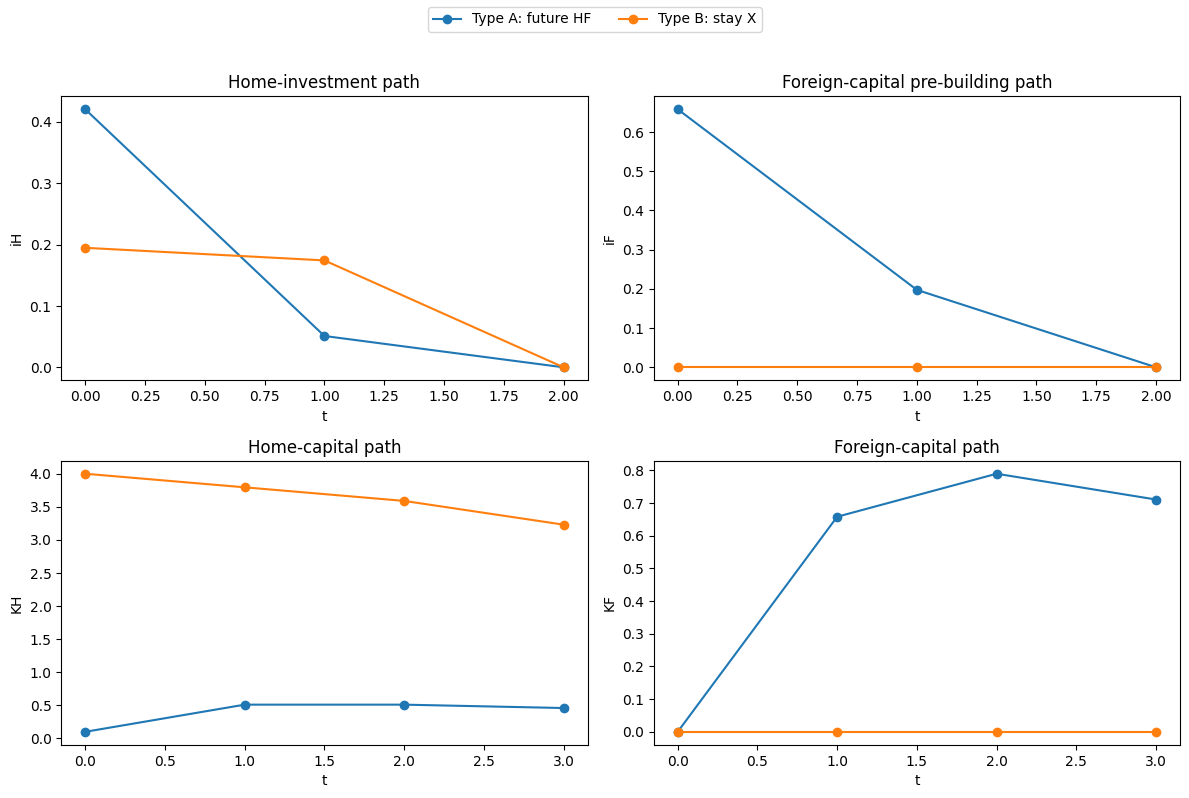

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

# Optional: to match the note's period-2 KKT exactly
# p.q_H = 1.0
# p.q_F = 1.0

KH_grid = np.linspace(0.10, 4.00, 45)
KF_grid = np.linspace(0.00, 2.50, 45)

# Full productivity grid if you still want to keep it for later
z_grid, s_grid_full, _ = rouwenhorst(n=7, rho=0.90, sigma_eps=0.12)

# Pick ONE chosen productivity state
chosen_s_idx_full = len(s_grid_full) - 2
chosen_s = float(s_grid_full[chosen_s_idx_full])

# Reduce to a single-point productivity grid
s_grid = np.array([chosen_s])
P_const = make_constant_productivity_transition(len(s_grid))   # = [[1.0]]

print("Chosen s:", chosen_s)

# Fast solve
grid_sol_p2 = solve_period2_grid_fast(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
)

grid_sol_p1 = solve_period1_grid_fast(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P_const,
    period2_sol=grid_sol_p2,
    p=p,
    cfg=cfg,
    radius=7,
    max_expansions=5,
)

grid_sol_p0 = solve_period0_grid_fast(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P_const,
    period1_sol=grid_sol_p1,
    p=p,
    cfg=cfg,
    radius=7,
    max_expansions=5,
)

# Choose two types from E_X at the chosen s
types = choose_two_types_one_s(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    chosen_s_idx=0,
    grid_sol_p0=grid_sol_p0,
    grid_sol_p1=grid_sol_p1,
    grid_sol_p2=grid_sol_p2,
    p=p,
    cfg=cfg,
    initial_prev_mode="X",
)

type_A = types["future_hf"]
type_B = types["stay_x"]

print("Type A (future HF):", type_A)
print("Type B (stay X):   ", type_B)


#if type_A is not None:
#   print_path_summary(type_A, "Type A: future HF")
#if type_B is not None:
#    print_path_summary(type_B, "Type B: stay X")

# Plot paths if both exist
rows = [r for r in [type_A, type_B] if r is not None]
labels = []
if type_A is not None:
    labels.append("Type A: future HF")
if type_B is not None:
    labels.append("Type B: stay X")

if len(rows) >= 1:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

    ax = axes[0, 0]
    for row, label in zip(rows, labels):
        ax.plot([0, 1, 2], [row["iH0"], row["iH1"], row["iH2"]], marker="o", label=label)
    ax.set_xlabel("t")
    ax.set_ylabel("iH")
    ax.set_title("Home-investment path")

    ax = axes[0, 1]
    for row, label in zip(rows, labels):
        ax.plot([0, 1, 2], [row["iF0"], row["iF1"], row["iF2"]], marker="o", label=label)
    ax.set_xlabel("t")
    ax.set_ylabel("iF")
    ax.set_title("Foreign-capital pre-building path")

    ax = axes[1, 0]
    for row, label in zip(rows, labels):
        ax.plot([0, 1, 2, 3], [row["KH0"], row["KH1"], row["KH2"], row["KH3"]], marker="o", label=label)
    ax.set_xlabel("t")
    ax.set_ylabel("KH")
    ax.set_title("Home-capital path")

    ax = axes[1, 1]
    for row, label in zip(rows, labels):
        ax.plot([0, 1, 2, 3], [row["KF0"], row["KF1"], row["KF2"], row["KF3"]], marker="o", label=label)
    ax.set_xlabel("t")
    ax.set_ylabel("KF")
    ax.set_title("Foreign-capital path")

    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", ncol=len(labels))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

## Fixed S with different S_0 but similar profits

In [90]:
import numpy as np
import matplotlib.pyplot as plt

cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.00, 45)
KF_grid = np.linspace(0.00, 2.50, 45)

# ------------------------------------------------------------
# Choose any two positive productivities you want
# These do NOT need to come from the old Markov grid.
# ------------------------------------------------------------
s_high = 1.5
s_low  = 0.90

print("Solving high-s model...")
model_high = solve_constant_s_model(
    s_value=s_high,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    p=p,
    cfg=cfg,
    radius=7,
    max_expansions=5,
)

print("Solving low-s model...")
model_low = solve_constant_s_model(
    s_value=s_low,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    p=p,
    cfg=cfg,
    radius=7,
    max_expansions=5,
)

pair = choose_two_types_different_s(
    model_high_s=model_high,
    model_low_s=model_low,
    initial_prev_mode="X",
    require_KH_ordering=True,
)

type_A = pair["type_A"]   # high s, future HF
type_B = pair["type_B"]   # low s, stay X

#print_matched_pair_summary(type_A, type_B, pair["profit_gap"])
print_path_summary(type_A, "Type A: high s, future HF")
print_path_summary(type_B, "Type B: low s, stay X")

Solving high-s model...
Solving low-s model...

=== Type A: high s, future HF ===
Initial: KH0=0.189, KF0=0.000, s=1.500
Modes:   t0=X, t1=HF, t2=HF
iH path: [0.462, 0.063, 0.000]
iF path: [0.909, 0.034, 0.000]
KH path: [0.189, 0.632, 0.632, 0.569]
KF path: [0.000, 0.909, 0.852, 0.767]
At t=2: s2=1.500, cutoff=0.215, above_cutoff=True

=== Type B: low s, stay X ===
Initial: KH0=0.455, KF0=0.000, s=0.900
Modes:   t0=X, t1=X, t2=X
iH path: [0.045, 0.045, 0.000]
iF path: [0.000, 0.000, 0.000]
KH path: [0.455, 0.455, 0.455, 0.409]
KF path: [0.000, 0.000, 0.000, 0.000]
At t=2: s2=0.900, cutoff=inf, above_cutoff=False


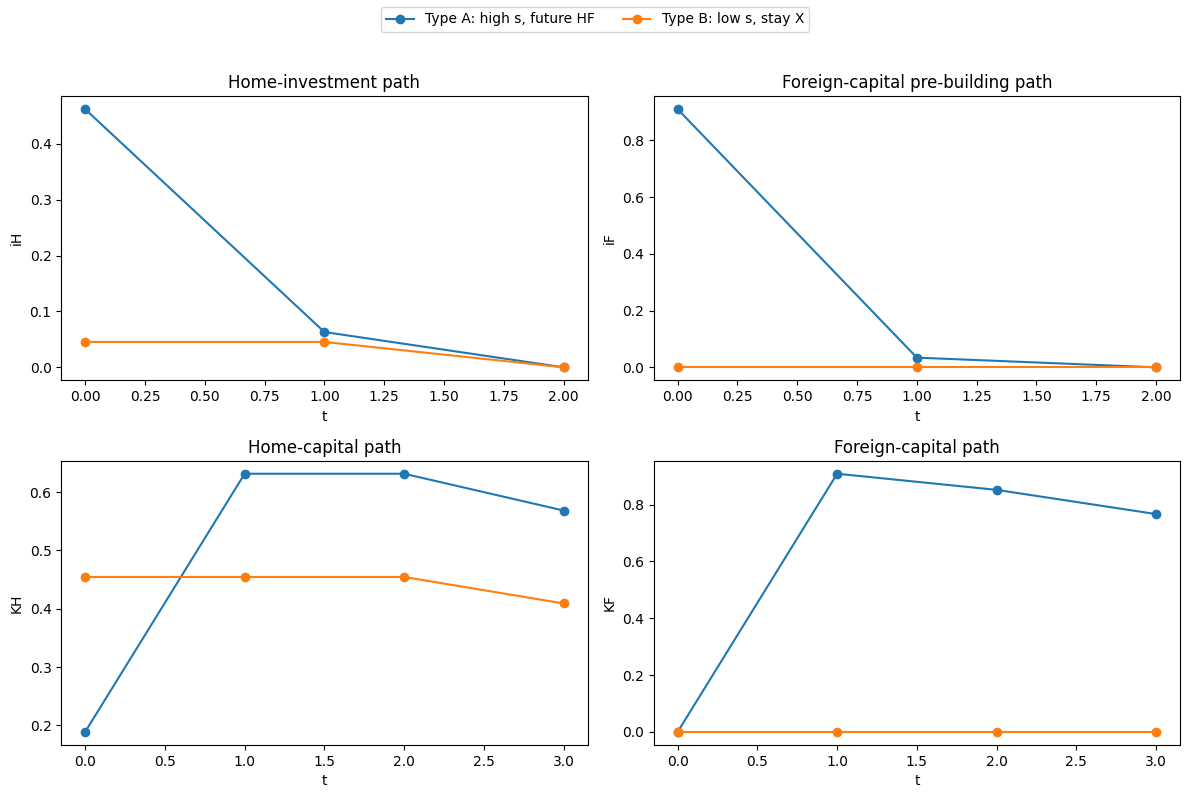

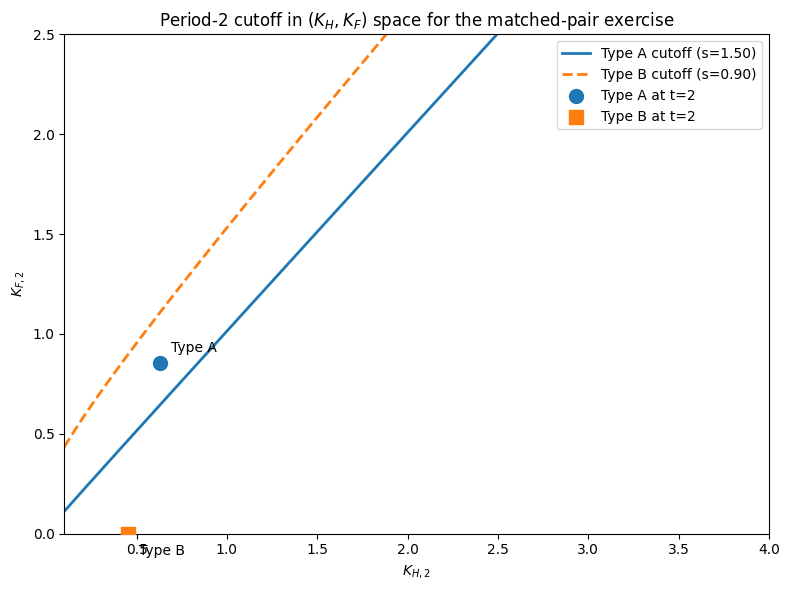

In [91]:
rows = [type_A, type_B]
labels = ["Type A: high s, future HF", "Type B: low s, stay X"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

ax = axes[0, 0]
for row, label in zip(rows, labels):
    ax.plot([0, 1, 2], [row["iH0"], row["iH1"], row["iH2"]], marker="o", label=label)
ax.set_xlabel("t")
ax.set_ylabel("iH")
ax.set_title("Home-investment path")

ax = axes[0, 1]
for row, label in zip(rows, labels):
    ax.plot([0, 1, 2], [row["iF0"], row["iF1"], row["iF2"]], marker="o", label=label)
ax.set_xlabel("t")
ax.set_ylabel("iF")
ax.set_title("Foreign-capital pre-building path")

ax = axes[1, 0]
for row, label in zip(rows, labels):
    ax.plot([0, 1, 2, 3], [row["KH0"], row["KH1"], row["KH2"], row["KH3"]], marker="o", label=label)
ax.set_xlabel("t")
ax.set_ylabel("KH")
ax.set_title("Home-capital path")

ax = axes[1, 1]
for row, label in zip(rows, labels):
    ax.plot([0, 1, 2, 3], [row["KF0"], row["KF1"], row["KF2"], row["KF3"]], marker="o", label=label)
ax.set_xlabel("t")
ax.set_ylabel("KF")
ax.set_title("Foreign-capital path")

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


def kf_threshold_given_kh(KH_vals, s_val, prev_mode, p):
    KH_vals = np.asarray(KH_vals, dtype=float)

    cost_term = (
        p.f_F_op - p.f_X_op
        + switching_cost(prev_mode, "HF", p)
        - switching_cost(prev_mode, "X", p)
    )

    inside = (
        omega_X(p) * np.maximum(KH_vals, p.eps) ** p.kappa
        + cost_term / (s_val ** p.rho)
    ) / omega_F(p)

    inside = np.maximum(inside, 0.0)
    return inside ** (1.0 / p.kappa)


KH_plot = np.linspace(KH_grid[0], KH_grid[-1], 300)

plt.figure(figsize=(8, 6))

# Type A cutoff (use its s and previous regime at t=2, usually mode1)
KF_star_A = kf_threshold_given_kh(KH_plot, type_A["s2"], type_A["mode1"], p)
plt.plot(KH_plot, KF_star_A, linewidth=2, label=f"Type A cutoff (s={type_A['s2']:.2f})")

# Type B cutoff
KF_star_B = kf_threshold_given_kh(KH_plot, type_B["s2"], type_B["mode1"], p)
plt.plot(KH_plot, KF_star_B, linewidth=2, linestyle="--", label=f"Type B cutoff (s={type_B['s2']:.2f})")

# Type A point
plt.scatter(type_A["KH2"], type_A["KF2"], s=100, marker="o", zorder=5, label="Type A at t=2")
plt.annotate("Type A", (type_A["KH2"], type_A["KF2"]), xytext=(8, 8), textcoords="offset points")

# Type B point
plt.scatter(type_B["KH2"], type_B["KF2"], s=100, marker="s", zorder=5, label="Type B at t=2")
plt.annotate("Type B", (type_B["KH2"], type_B["KF2"]), xytext=(8, -15), textcoords="offset points")

plt.xlabel(r"$K_{H,2}$")
plt.ylabel(r"$K_{F,2}$")
plt.title(r"Period-2 cutoff in $(K_H,K_F)$ space for the matched-pair exercise")
plt.xlim(KH_grid[0], KH_grid[-1])
plt.ylim(KF_grid[0], KF_grid[-1])
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.00, 20)
KF_grid = np.linspace(0.00, 2.50, 20)

s_high = 1.5
s_low  = 0.90

model_high_fixed = solve_constant_s_model(
    s_value=s_high,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    p=p,
    cfg=cfg,
    radius=7,
    max_expansions=5,
)

model_low_fixed = solve_constant_s_model(
    s_value=s_low,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    p=p,
    cfg=cfg,
    radius=7,
    max_expansions=5,
)

pair_fixed = choose_two_types_different_s(
    model_high_s=model_high_fixed,
    model_low_s=model_low_fixed,
    initial_prev_mode="X",
    require_KH_ordering=True,
)

type_A_fixed = pair_fixed["type_A"]
type_B_fixed = pair_fixed["type_B"]

#print_matched_pair_summary(type_A_fixed, type_B_fixed, pair_fixed["profit_gap"])

# deterministic simulation using the same generic simulator
sim_A_fixed = simulate_many_from_initial_state(
    model_bundle=model_high_fixed,
    KH0=type_A_fixed["KH0"],
    KF0=type_A_fixed["KF0"],
    s0_idx=type_A_fixed["s0_idx"],
    n_firms=1,
    stochastic=False,
)

sim_B_fixed = simulate_many_from_initial_state(
    model_bundle=model_low_fixed,
    KH0=type_B_fixed["KH0"],
    KF0=type_B_fixed["KF0"],
    s0_idx=type_B_fixed["s0_idx"],
    n_firms=1,
    stochastic=False,
)

print_path_summary(sim_A_fixed["rows"][0], "Type A fixed")
print_path_summary(sim_B_fixed["rows"][0], "Type B fixed")


=== Type A fixed ===
Initial: KH0=0.100, KF0=0.000, s=1.500
Modes:   t0=X, t1=HF, t2=HF
iH path: [0.215, 0.031, 0.000]
iF path: [0.395, 0.039, 0.000]
KH path: [0.100, 0.305, 0.305, 0.275]
KF path: [0.000, 0.395, 0.395, 0.355]
At t=2: s2=1.500, cutoff=0.722, above_cutoff=True

=== Type B fixed ===
Initial: KH0=0.511, KF0=0.000, s=0.900
Modes:   t0=X, t1=X, t2=X
iH path: [0.051, 0.051, 0.000]
iF path: [0.000, 0.000, 0.000]
KH path: [0.511, 0.511, 0.511, 0.459]
KF path: [0.000, 0.000, 0.000, 0.000]
At t=2: s2=0.900, cutoff=inf, above_cutoff=False


### M allowable code
1. First without M
2. Second with M

In [101]:
import numpy as np
import matplotlib.pyplot as plt

cfg = RegimeConfig(active_modes=("X", "HF"))

# Benchmark without M
p = ModelParams(use_M=False, alpha_M=0.0)

KH_grid = np.linspace(0.10, 4.00, 20)
KF_grid = np.linspace(0.00, 2.50, 20)
M_grid  = make_M_grid(p, M_max=0.0, n_M=1)

# Choose any two positive productivities
s_high = 1.50
s_low  = 0.90

print("Solving high-s model...")
model_high = solve_constant_s_model_M(
    s_value=s_high,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    M_grid=M_grid,
    p=p,
    cfg=cfg,
    radius_K=7,
    radius_M=0,
    max_expansions=4,
)

print("Solving low-s model...")
model_low = solve_constant_s_model_M(
    s_value=s_low,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    M_grid=M_grid,
    p=p,
    cfg=cfg,
    radius_K=7,
    radius_M=0,
    max_expansions=4,
)

pair = choose_two_types_different_s_M(
    model_high_s=model_high,
    model_low_s=model_low,
    initial_prev_mode="X",
    require_KH_ordering=True,
    require_same_M0=True,
)

type_A = pair["type_A"]   # high s, future HF
type_B = pair["type_B"]   # low s, stay X

print_path_summary_M(type_A, "Type A: high s, future HF")
print_path_summary_M(type_B, "Type B: low s, stay X")

Solving high-s model...
Solving low-s model...

=== Type A: high s, future HF ===
Initial: KH0=0.100, KF0=0.000, M0=0.000, s=1.500
Modes:   t0=X, t1=HF, t2=HF
iH path: [0.215, 0.031, 0.000]
iF path: [0.395, 0.039, 0.000]
iM path: [0.000, 0.000, 0.000]
KH path: [0.100, 0.305, 0.305, 0.275]
KF path: [0.000, 0.395, 0.395, 0.355]
M  path: [0.000, 0.000, 0.000, 0.000]

=== Type B: low s, stay X ===
Initial: KH0=0.511, KF0=0.000, M0=0.000, s=0.900
Modes:   t0=X, t1=X, t2=X
iH path: [0.051, 0.051, 0.000]
iF path: [0.000, 0.000, 0.000]
iM path: [0.000, 0.000, 0.000]
KH path: [0.511, 0.511, 0.511, 0.459]
KF path: [0.000, 0.000, 0.000, 0.000]
M  path: [0.000, 0.000, 0.000, 0.000]


In [102]:
cfg = RegimeConfig(active_modes=("X", "HF"))

# Model with M
p = ModelParams(
    use_M=True,
    alpha_M=0.25,
    phi_M=1.5,
    q_M=1.0,
    xi_M=0.20,
    delta_M=0.10,
)

KH_grid = np.linspace(0.10, 4.00, 20)
KF_grid = np.linspace(0.00, 2.50, 20)
M_grid  = make_M_grid(p, M_max=1.50, n_M=11)

s_high = 1.50
s_low  = 0.90

print("Solving high-s model with M...")
model_high_M = solve_constant_s_model_M(
    s_value=s_high,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    M_grid=M_grid,
    p=p,
    cfg=cfg,
    radius_K=7,
    radius_M=2,
    max_expansions=4,
)

print("Solving low-s model with M...")
model_low_M = solve_constant_s_model_M(
    s_value=s_low,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    M_grid=M_grid,
    p=p,
    cfg=cfg,
    radius_K=7,
    radius_M=2,
    max_expansions=4,
)

pair_M = choose_two_types_different_s_M(
    model_high_s=model_high_M,
    model_low_s=model_low_M,
    initial_prev_mode="X",
    require_KH_ordering=True,
    require_same_M0=True,
)

type_A_M = pair_M["type_A"]
type_B_M = pair_M["type_B"]

print_path_summary_M(type_A_M, "Type A with M: high s, future HF")
print_path_summary_M(type_B_M, "Type B with M: low s, stay X")

Solving high-s model with M...
Solving low-s model with M...

=== Type A with M: high s, future HF ===
Initial: KH0=0.100, KF0=0.000, M0=0.000, s=1.500
Modes:   t0=X, t1=HF, t2=HF
iH path: [0.215, 0.031, 0.000]
iF path: [0.395, 0.039, 0.000]
iM path: [0.000, 0.000, 0.000]
KH path: [0.100, 0.305, 0.305, 0.275]
KF path: [0.000, 0.395, 0.395, 0.355]
M  path: [0.000, 0.000, 0.000, 0.000]

=== Type B with M: low s, stay X ===
Initial: KH0=0.511, KF0=0.000, M0=0.000, s=0.900
Modes:   t0=X, t1=X, t2=X
iH path: [0.051, 0.051, 0.000]
iF path: [0.000, 0.000, 0.000]
iM path: [0.000, 0.000, 0.000]
KH path: [0.511, 0.511, 0.511, 0.459]
KF path: [0.000, 0.000, 0.000, 0.000]
M  path: [0.000, 0.000, 0.000, 0.000]


## Stochastic S

In [85]:
cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.00, 45)
KF_grid = np.linspace(0.00, 2.50, 45)

# Start with n=7. Move to 9 if you want a robustness check.
z_grid, s_grid_markov, P_markov = rouwenhorst(n=11, rho=0.75, sigma_eps=0.18)

model_markov = solve_model_fast_bundle(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid_markov,
    P=P_markov,
    p=p,
    cfg=cfg,
    radius=7,
    max_expansions=5,
)

# Choose initial productivities from the grid
# Example: one relatively high, one relatively low
s_high_idx = (len(s_grid_markov) - 1) // 2
s_low_idx = s_high_idx - 2

print("s_high =", s_grid_markov[s_high_idx], " | s_low =", s_grid_markov[s_low_idx])

pair_markov = choose_two_types_different_s_markov(
    model_bundle=model_markov,
    s_high_idx=s_high_idx,
    s_low_idx=s_low_idx,
    initial_prev_mode="X",
    require_KH_ordering=True,
)

type_A_stoch = pair_markov["type_A"]
type_B_stoch = pair_markov["type_B"]

print("\nMatched stochastic initial types")
print("Type A:", type_A_stoch)
print("Type B:", type_B_stoch)
print("Initial export-profit gap:", pair_markov["profit_gap"])

s_high = 1.0  | s_low = 0.7087688419807135

Matched stochastic initial types
Type A: {'KH0': 0.4545454545454546, 'KF0': 0.0, 's0_idx': 5, 's0': 1.0, 'mode0': 'X', 'iH0': 0.1340909090909091, 'iF0': 0.0, 'initial_profit_X': 0.25077247659271584}
Type B: {'KH0': 0.8090909090909091, 'KF0': 0.0, 's0_idx': 3, 's0': 0.7087688419807135, 'mode0': 'X', 'iH0': 0.16954545454545455, 'iF0': 0.0, 'initial_profit_X': 0.25137932019255926}
Initial export-profit gap: 0.0006068435998434207



=== Type A stochastic ===
n firms: 1000
Share in HF at t=2: 0.000
Share above t=2 cutoff: 0.000
Mean iF0: 0.000
Mean iF1: 0.000
Mean KH2: 0.543
Mean KF2: 0.000

=== Type B stochastic ===
n firms: 1000
Share in HF at t=2: 0.000
Share above t=2 cutoff: 0.000
Mean iF0: 0.000
Mean iF1: 0.000
Mean KH2: 0.809
Mean KF2: 0.000


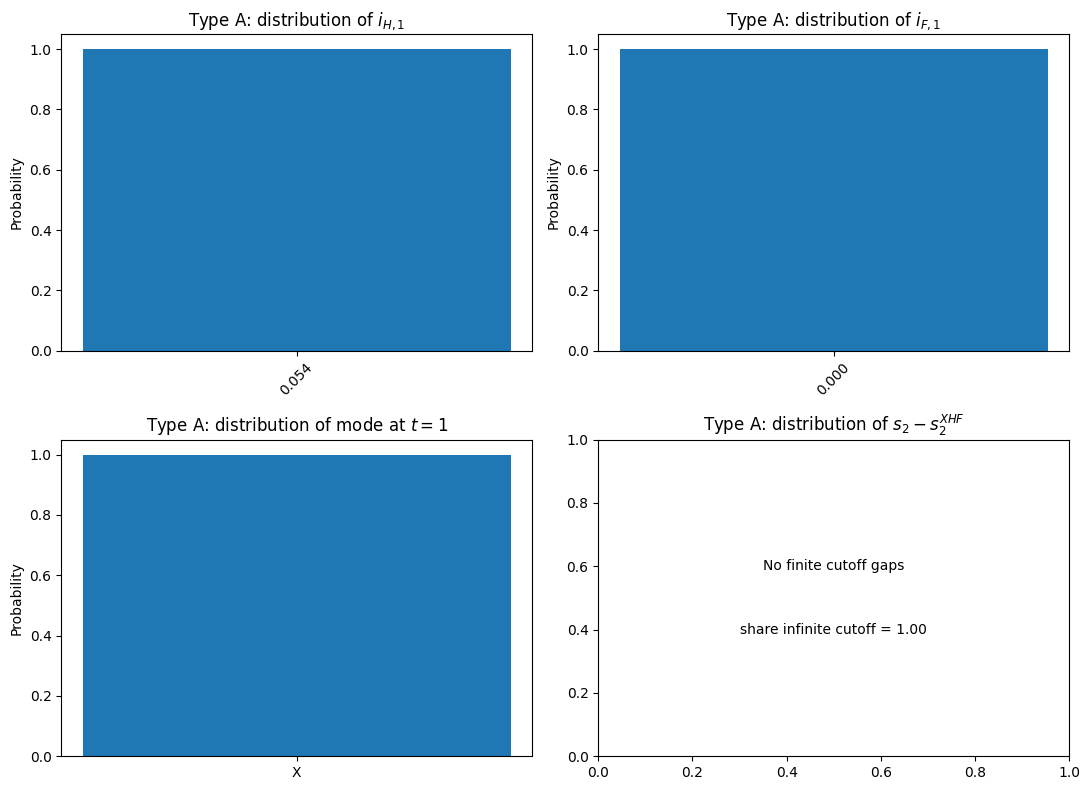

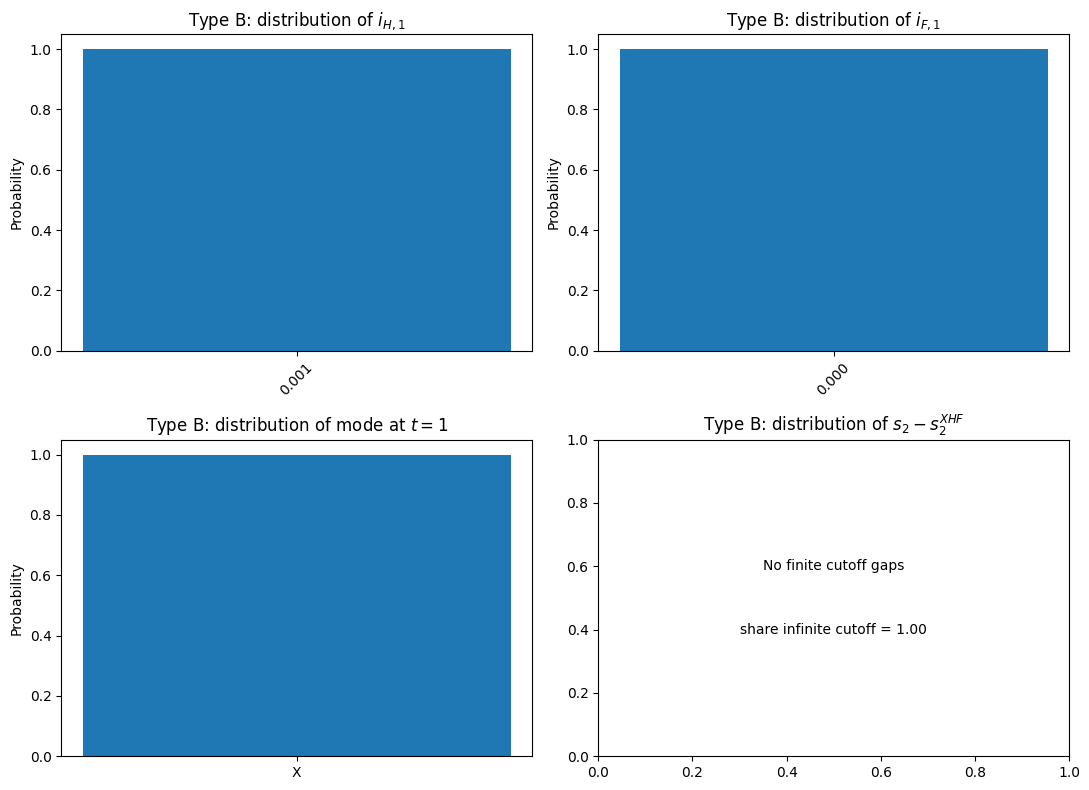

s_high=0.597, hf_share_A=0.000, hf_share_B=0.000, profit_gap=0.0001
s_high=0.709, hf_share_A=0.000, hf_share_B=0.000, profit_gap=0.0004
s_high=0.842, hf_share_A=0.000, hf_share_B=0.000, profit_gap=0.0000
s_high=1.000, hf_share_A=0.000, hf_share_B=0.000, profit_gap=0.0003
s_high=1.188, hf_share_A=0.000, hf_share_B=0.000, profit_gap=0.0000
s_high=1.411, hf_share_A=0.000, hf_share_B=0.000, profit_gap=0.0006
s_high=1.676, hf_share_A=0.000, hf_share_B=0.000, profit_gap=0.0007
s_high=1.991, hf_share_A=1.000, hf_share_B=0.000, profit_gap=0.0001
s_high=2.364, hf_share_A=1.000, hf_share_B=0.000, profit_gap=0.0001


In [86]:
sim_A_stoch = simulate_many_from_initial_state(
    model_bundle=model_markov,
    KH0=type_A_stoch["KH0"],
    KF0=type_A_stoch["KF0"],
    s0_idx=type_A_stoch["s0_idx"],
    n_firms=1000,
    seed=123,
    stochastic=True,
)

sim_B_stoch = simulate_many_from_initial_state(
    model_bundle=model_markov,
    KH0=type_B_stoch["KH0"],
    KF0=type_B_stoch["KF0"],
    s0_idx=type_B_stoch["s0_idx"],
    n_firms=1000,
    seed=456,
    stochastic=True,
)

summarize_simulation(sim_A_stoch, "Type A stochastic")
summarize_simulation(sim_B_stoch, "Type B stochastic")

# Plot distributions of key variables
import numpy as np
import matplotlib.pyplot as plt

def discrete_pmf(values, decimals=6):
    vals = np.round(np.asarray(values, dtype=float), decimals=decimals)
    u, c = np.unique(vals, return_counts=True)
    p = c / c.sum()
    return u, p

def plot_type_distributions(sim, label):
    rows = sim["rows"]

    iH1 = [r["iH1"] for r in rows]
    iF1 = [r["iF1"] for r in rows]
    mode1 = [r["mode1"] for r in rows]
    gap2 = np.array([r["s2"] - r["s2_cutoff_XHF"] for r in rows], dtype=float)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    # iH1 pmf
    u, p = discrete_pmf(iH1)
    axes[0, 0].bar(np.arange(len(u)), p)
    axes[0, 0].set_xticks(np.arange(len(u)))
    axes[0, 0].set_xticklabels([f"{x:.3f}" for x in u], rotation=45)
    axes[0, 0].set_title(rf"{label}: distribution of $i_{{H,1}}$")
    axes[0, 0].set_ylabel("Probability")

    # iF1 pmf
    u, p = discrete_pmf(iF1)
    axes[0, 1].bar(np.arange(len(u)), p)
    axes[0, 1].set_xticks(np.arange(len(u)))
    axes[0, 1].set_xticklabels([f"{x:.3f}" for x in u], rotation=45)
    axes[0, 1].set_title(rf"{label}: distribution of $i_{{F,1}}$")
    axes[0, 1].set_ylabel("Probability")

    # mode1 distribution
    modes, counts = np.unique(mode1, return_counts=True)
    probs = counts / counts.sum()
    axes[1, 0].bar(modes, probs)
    axes[1, 0].set_title(rf"{label}: distribution of mode at $t=1$")
    axes[1, 0].set_ylabel("Probability")

    # gap to cutoff at t=2
    finite_mask = np.isfinite(gap2)
    gap2_finite = gap2[finite_mask]
    share_inf = 1.0 - finite_mask.mean()

    if len(gap2_finite) > 0:
        axes[1, 1].hist(gap2_finite, bins=20)
        axes[1, 1].axvline(0.0, linestyle="--")
        axes[1, 1].set_title(rf"{label}: distribution of $s_2 - s_2^{{XHF}}$")
        axes[1, 1].set_xlabel(r"$s_2 - s_2^{XHF}$")
        axes[1, 1].text(
            0.02, 0.95,
            f"share infinite cutoff = {share_inf:.2f}",
            transform=axes[1, 1].transAxes,
            va="top"
        )
    else:
        axes[1, 1].text(
            0.5, 0.6,
            "No finite cutoff gaps",
            ha="center", va="center"
        )
        axes[1, 1].text(
            0.5, 0.4,
            f"share infinite cutoff = {share_inf:.2f}",
            ha="center", va="center"
        )
        axes[1, 1].set_title(rf"{label}: distribution of $s_2 - s_2^{{XHF}}$")

    plt.tight_layout()
    plt.show()

plot_type_distributions(sim_A_stoch, "Type A")
plot_type_distributions(sim_B_stoch, "Type B")

# Different S 
def hf_share_from_type(model_bundle, type_row, n_firms=300, seed=123):
    sim = simulate_many_from_initial_state(
        model_bundle=model_bundle,
        KH0=type_row["KH0"],
        KF0=type_row["KF0"],
        s0_idx=type_row["s0_idx"],
        n_firms=n_firms,
        seed=seed,
        stochastic=True,
    )
    hf_share = np.mean([r["mode2"] == "HF" for r in sim["rows"]])
    return hf_share, sim

def scan_s_high_idx_for_partial_transition(
    model_bundle: Dict[str, object],
    s_low_idx: int,
    candidate_high_idxs: list[int],
    n_firms: int = 300,
    seed: int = 123,
    require_KH_ordering: bool = True,
) -> list[dict]:
    """
    Cheap scan:
    - reuses the same solved Markov model
    - only varies the high initial productivity index
    - chooses a matched pair each time
    - computes Type A and Type B HF shares
    """
    out = []

    for s_high_idx in candidate_high_idxs:
        if s_high_idx <= s_low_idx:
            continue

        try:
            pair = choose_two_types_different_s_markov(
                model_bundle=model_bundle,
                s_high_idx=s_high_idx,
                s_low_idx=s_low_idx,
                initial_prev_mode="X",
                require_KH_ordering=require_KH_ordering,
            )

            type_A = pair["type_A"]
            type_B = pair["type_B"]

            hf_share_A, _ = hf_share_from_type(model_bundle, type_A, n_firms=n_firms, seed=seed)
            hf_share_B, _ = hf_share_from_type(model_bundle, type_B, n_firms=n_firms, seed=seed + 1)

            out.append({
                "s_high_idx": s_high_idx,
                "s_high": float(model_bundle["s_grid"][s_high_idx]),
                "s_low_idx": s_low_idx,
                "s_low": float(model_bundle["s_grid"][s_low_idx]),
                "KH0_A": type_A["KH0"],
                "KH0_B": type_B["KH0"],
                "profit_gap": pair["profit_gap"],
                "hf_share_A": hf_share_A,
                "hf_share_B": hf_share_B,
                "type_A": type_A,
                "type_B": type_B,
            })

        except ValueError:
            continue

    return out

# Example: model_markov already solved once
# s_low_idx fixed
s_low_idx = 1

# Try several higher initial productivity points
candidate_high_idxs = list(range(s_low_idx + 1, len(model_markov["s_grid"])))

scan_results = scan_s_high_idx_for_partial_transition(
    model_bundle=model_markov,
    s_low_idx=s_low_idx,
    candidate_high_idxs=candidate_high_idxs,
    n_firms=300,   # keep this small during search
    seed=123,
)

for r in scan_results:
    print(
        f"s_high={r['s_high']:.3f}, "
        f"hf_share_A={r['hf_share_A']:.3f}, "
        f"hf_share_B={r['hf_share_B']:.3f}, "
        f"profit_gap={r['profit_gap']:.4f}"
    )

In [87]:
# Example: same model_markov as before
# Choose one high-s and one low-s index
s_low_idx = len(model_markov["s_grid"]) - 3
s_high_idx = len(model_markov["s_grid"]) - 2

pair_boundary = choose_two_types_markov_boundary_based(
    model_bundle=model_markov,
    s_high_idx=s_high_idx,
    s_low_idx=s_low_idx,
    target_hf_share_A=0.50,   # aim for an interior transition rate
    max_hf_share_B=0.05,      # want B to mostly stay X
    shortlist_A=8,
    shortlist_B=12,
    n_firms_eval=300,         # cheap during search
    seed_A=123,
    seed_B=999,
)

type_A = pair_boundary["type_A"]
type_B = pair_boundary["type_B"]

print_boundary_based_pair(type_A, type_B)


=== Boundary-based stochastic pair ===

Type A (high s, near boundary)
  s_A       = 1.991
  KH0_A     = 0.543
  piX_A     = 0.708918
  gap_A     = 0.051975
  HF shareA = 0.000

Type B (low s, higher KH, similar profits)
  s_B       = 1.676
  KH0_B     = 0.720
  piX_B     = 0.706571
  gap_B     = 0.179625
  HF shareB = 0.000
  |piX_A-piX_B| = 0.002347


In [88]:
sim_A_stoch = simulate_many_from_initial_state(
    model_bundle=model_markov,
    KH0=type_A["KH0"],
    KF0=type_A["KF0"],
    s0_idx=type_A["s0_idx"],
    n_firms=2000,
    seed=123,
    stochastic=True,
)

sim_B_stoch = simulate_many_from_initial_state(
    model_bundle=model_markov,
    KH0=type_B["KH0"],
    KF0=type_B["KF0"],
    s0_idx=type_B["s0_idx"],
    n_firms=2000,
    seed=456,
    stochastic=True,
)

summarize_simulation(sim_A_stoch, "Type A stochastic")
summarize_simulation(sim_B_stoch, "Type B stochastic")


=== Type A stochastic ===
n firms: 2000
Share in HF at t=2: 0.000
Share above t=2 cutoff: 0.000
Mean iF0: 0.000
Mean iF1: 0.000
Mean KH2: 1.167
Mean KF2: 0.000

=== Type B stochastic ===
n firms: 2000
Share in HF at t=2: 0.000
Share above t=2 cutoff: 0.000
Mean iF0: 0.000
Mean iF1: 0.000
Mean KH2: 1.075
Mean KF2: 0.000
